# Who should the bank call? Predicting term-deposit subscriptions

**The question:** A Portuguese bank ran telemarketing campaigns from May 2008 to November 2010. Only 11.3% of customers subscribed to a term deposit. Can we find the customers worth calling first?

**What we found**
- Only 3.3% of customers had a previous campaign success, but 65.1% of them subscribed again, against 14.2% after a previous failure and 8.8% with no history.
- Cellular contact converted at 14.7% against 5.2% for landline.
- Conversion falls with repeated calls, from 13.0% on the first call to 3.1% beyond ten.
- The economic climate matters most: subscribers were contacted when Euribor was low (median 1.27% against 4.86%).
- A model can rank customers about 4 times better than random calling, but it relies heavily on the economic period, so it needs retraining.

**How to read this notebook:** it has seven chapters, and each ends with a **So what** line that says what the finding means for the marketing team.

### Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model which will help the bank marketing team to know which customer will buy the product.

Task3:-Suggestions to the Bank market team to make  customers  buy the product.


![Project workflow](project_workflow_diagram.png)

### Import the libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing all the other required libraries for the project 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [4]:

# Import RandomOverSampler and imbalanced-learn Pipeline

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

In [5]:
from xgboost import XGBClassifier

In [6]:
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

# 1. DEFINE YOUR COLOUR PALETTE
BRAND_PALETTE = ['#E3F4F1', '#A8DCD3', '#5DBBB5', '#2A9099', '#1B6A8A', '#134A73', '#0B2C4D']

# 2. CREATE REGISTERED COLORMAPS
brand_cmap = LinearSegmentedColormap.from_list('brand_gradient', BRAND_PALETTE)
plt.colormaps.register(cmap=brand_cmap, force=True)

# 3. OVERWRITE GLOBAL GRAPHIC DEFAULTS
plt.rcParams.update({
    # Automatically assigns your corporate colors to any bar, line, or chart element
    'axes.prop_cycle': cycler(color=[BRAND_PALETTE[4], BRAND_PALETTE[2], BRAND_PALETTE[5], BRAND_PALETTE[3]]),

    # Canvas Sizing & Quality
    'figure.figsize': (7, 5),          # Default canvas size set to your preferred (7, 5)
    'figure.dpi': 110,
    
    # Typography Engine
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Calibri', 'DejaVu Sans'],
    'font.size': 11,
    
    # Title Formats
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    
    # Palette Mapping
    'axes.labelcolor': BRAND_PALETTE[-1],
    'text.color': BRAND_PALETTE[-1],
    'xtick.color': BRAND_PALETTE[-1],
    'ytick.color': BRAND_PALETTE[-1],
    'axes.edgecolor': '#C9D6DF',
    
    # Border Frame Adjustments
    'axes.spines.top': False,
    'axes.spines.right': False,
    
    'axes.grid': False,              
})


# Chapter 1 · The data: what do we have?

### Download the dataset 

In [7]:
df = pd.read_csv("bank-additional-full.csv",sep=';')

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Dictionary

In [9]:
data_dictionary = pd.DataFrame({
    'Column': ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
               'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
               'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
    'Meaning': ['Customer age', 'Type of job', 'Marital status', 'Education level',
                'Has credit in default', 'Has a housing loan', 'Has a personal loan',
                'Contact method of the last call', 'Month of the last contact', 'Day of the week of the last contact',
                'Last call duration in seconds (known only after the call)',
                'Contacts made to this customer in this campaign',
                'Days since a previous campaign contact (999 = not contacted in a previous campaign)',
                'Contacts made before this campaign', 'Outcome of the previous campaign',
                'Employment variation rate (quarterly)', 'Consumer price index (monthly)',
                'Consumer confidence index (monthly)', '3-month Euribor rate (daily)',
                'Number of employees (quarterly)', 'Subscribed to a term deposit?']
})
display(data_dictionary)

,Column,Meaning
0,age,Customer age
1,job,Type of job
2,marital,Marital status
3,education,Education level
4,default,Has credit in default
5,housing,Has a housing loan
6,loan,Has a personal loan
7,contact,Contact method of the last call
8,month,Month of the last contact
9,day_of_week,Day of the week of the last contact


### Understand the Dataset 

In [10]:
df.shape

(41188, 21)

In [11]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [12]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Checking the missing and duplicate values in this dataset 

In [14]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(12)

In [16]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


### Found 12 duplicate values so Deleting them before going ahead

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(41176, 21)

**So what:** the file has 41,188 rows, which become 41,176 after removing 12 duplicates. There are no missing cells, and `unknown` is kept as its own category (see Chapter 2).

# Chapter 2 · The customers: only 11% say yes

### Only 11% subscribe, so accuracy will mislead us

In [19]:
df['y'].value_counts()

y
no     36537
yes     4639
Name: count, dtype: int64

In [20]:
df['y'].value_counts(normalize=True) * 100 #helps us understand what percentage of customers have/have not subscribed to term deposit. 

y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64

### This tells us something extremely important.

1. The dataset is imbalanced.

2. Only about 11% of customers subscribe.

3. That means this would be a terrible model: "Predict no for everybody."

4. It would get roughly 88.7% accuracy, but it would be useless to the marketing team because it identifies zero customers who will buy.

### Let us now visualise the target 

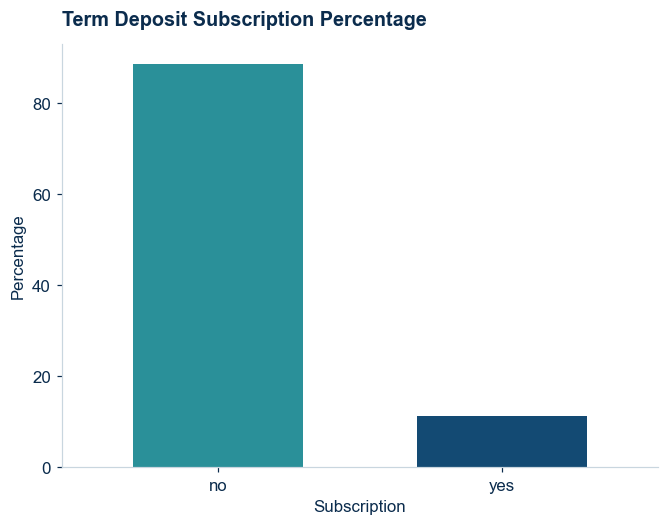

In [21]:
target_pct = df['y'].value_counts(normalize=True) * 100

plt.figure(figsize=(7,5))

target_pct.plot(kind='bar',color=[BRAND_PALETTE[3], BRAND_PALETTE[5]], width=0.6)

plt.title('Term Deposit Subscription Percentage',loc='left')
plt.xlabel('Subscription')
plt.ylabel('Percentage')

plt.xticks(rotation=0)
plt.gca().grid(axis='x', visible=False)
plt.show()

#### The target variable is highly imbalanced. Approximately 88.73% of customers did not subscribe to the term deposit, while only 11.27% subscribed. Therefore, accuracy alone is not an appropriate metric for evaluating the predictive models. Precision, recall, F1-score, ROC-AUC and PR-AUC will also be considered.

### Understand the numerical variables

In [22]:
df['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

In [23]:
df['campaign'].describe()

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

In [24]:
df['previous'].describe()

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

### Understanding categorical variables 

In [25]:
df['job'].value_counts()

job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [26]:
df['education'].value_counts()

education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

In [27]:
df['marital'].value_counts()

marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

In [28]:
df['contact'].value_counts()

contact
cellular     26135
telephone    15041
Name: count, dtype: int64

In [29]:
df['poutcome'].value_counts()

poutcome
nonexistent    35551
failure         4252
success         1373
Name: count, dtype: int64

### Checking unknown values 

In [30]:
# Count 'unknown' values in each column

unknown_counts = {}

for col in df.select_dtypes(include='object').columns:
    unknown_counts[col] = (df[col] == 'unknown').sum()

unknown_counts = pd.Series(unknown_counts).sort_values(ascending=False)

unknown_counts

default        8596
education      1730
housing         990
loan            990
job             330
marital          80
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

In [31]:
unknown_percentage = (unknown_counts / len(df)) * 100

unknown_summary = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Unknown Percentage': unknown_percentage.round(2)
})

unknown_summary

,Unknown Count,Unknown Percentage
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19
contact,0,0.00
month,0,0.00
day_of_week,0,0.00
poutcome,0,0.00


**Insight:** `default` has 20.9% `unknown` values and `education` 4.2%, while the other columns have very few. We keep `unknown` as a category rather than guess it.

### check numerical distributions 

In [32]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

numeric_columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

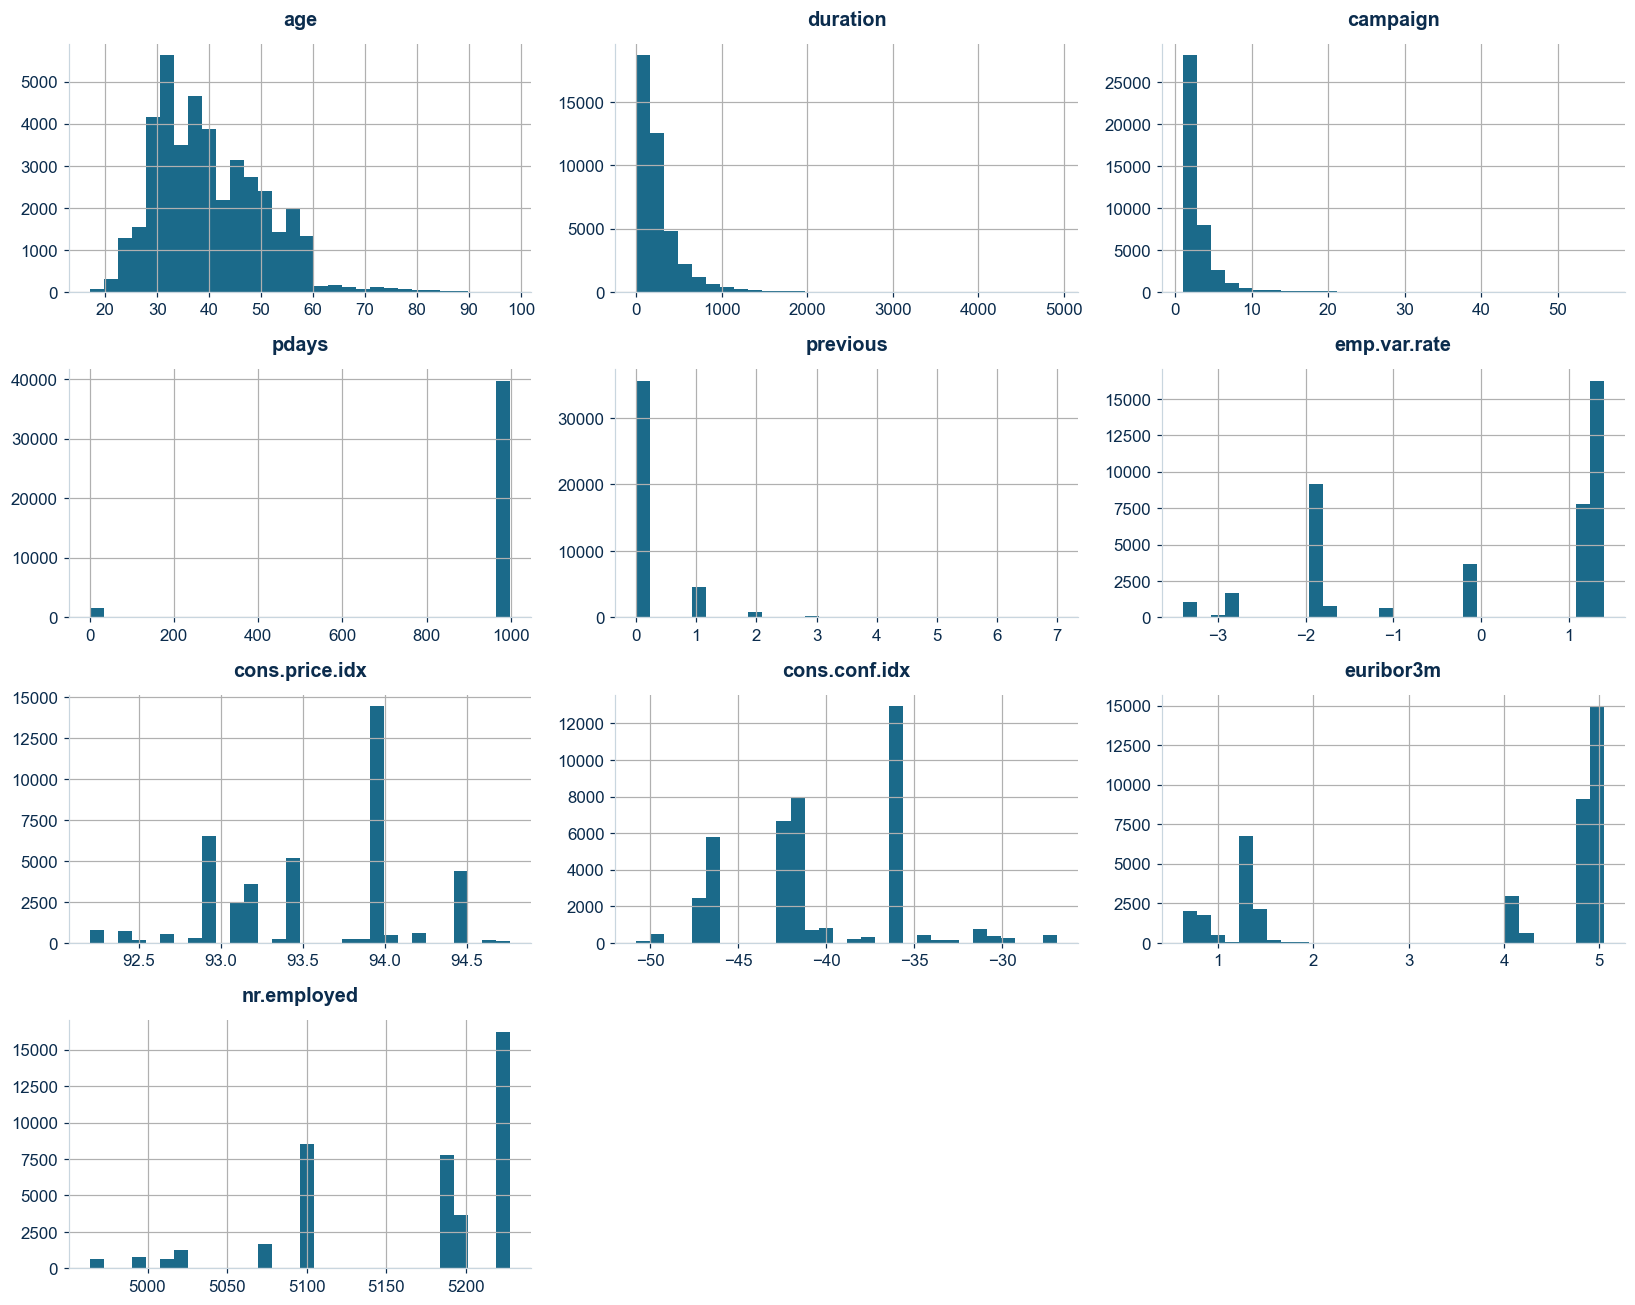

In [33]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

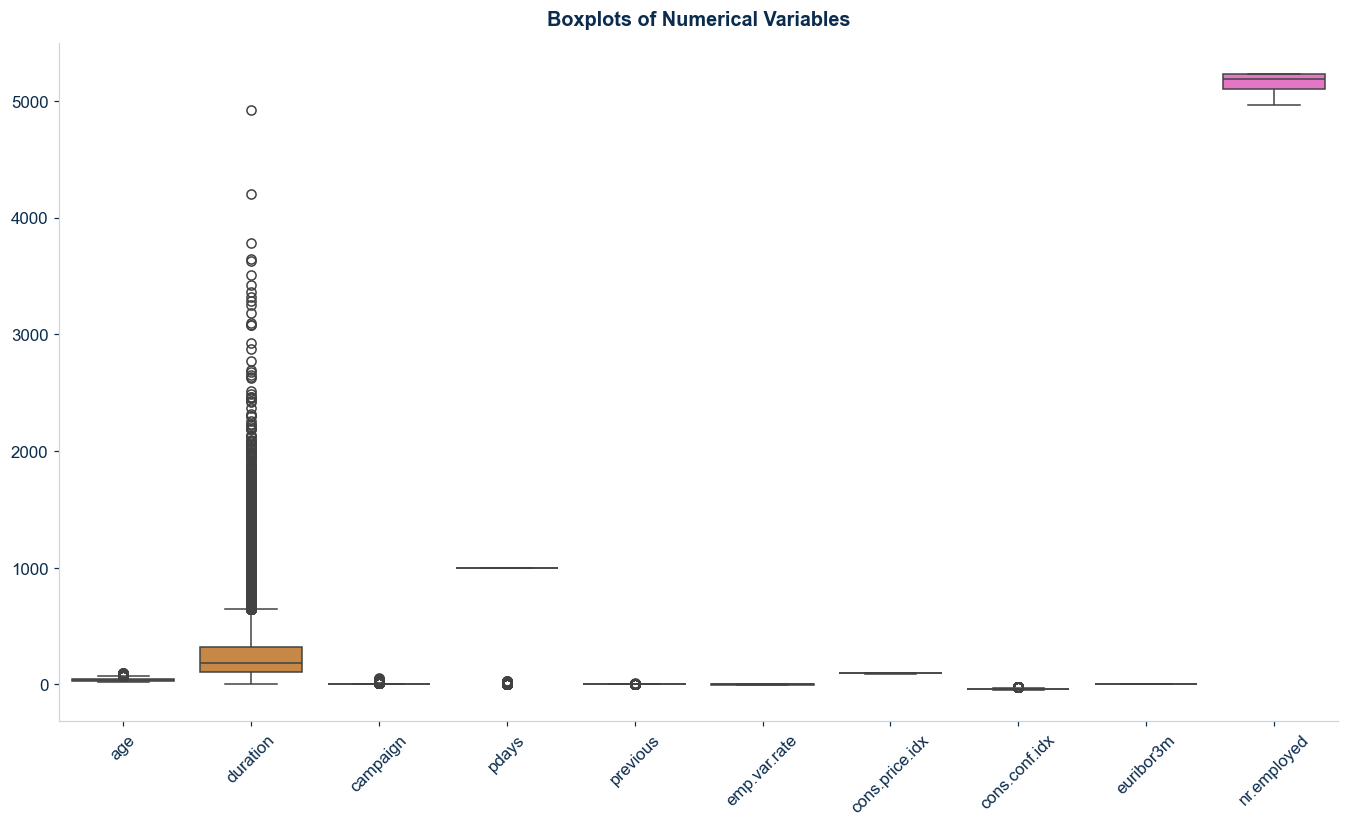

In [34]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Variables')
plt.show()

### Distribution and Outlier Analysis

The numerical variables were examined using histograms and boxplots to identify skewness and potential outliers.

Several variables showed skewed distributions and observations outside the typical boxplot range. These observations were investigated as potential outliers.

However, an observation identified as an outlier by the boxplot is not necessarily an incorrect observation. In this dataset, extreme values can represent genuine customer behaviour, such as customers receiving a larger number of campaign contacts.

Therefore, the observations were not automatically removed solely because they appeared as statistical outliers. Removing legitimate observations could result in loss of useful information.

For the machine-learning stage, numerical missing values were handled using median imputation and numerical variables were standardised using StandardScaler within the preprocessing pipeline. This preprocessing was applied after the train-test split to avoid data leakage.

### Correlation analysis

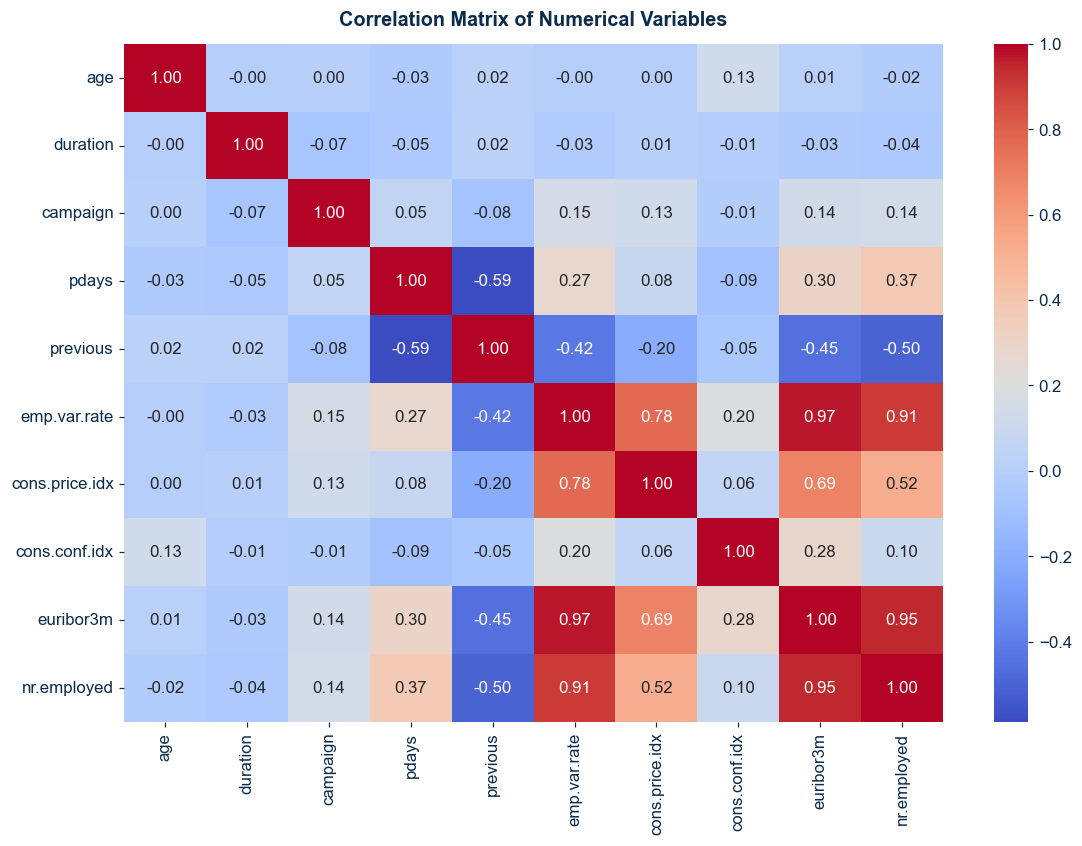

In [35]:
plt.figure(figsize=(12, 8))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

**Insight:** employment variation rate, Euribor and number of employees are almost the same signal (correlations of 0.91-0.97), and `pdays` and `previous` move in opposite directions (-0.59).

**So what:** the data is clean enough to model. The class imbalance and the overlapping economic columns are the two things the model design must respect.

# Chapter 3 · The drivers: who subscribes, and when does calling stop paying off?

In [36]:
df.groupby('y')['duration'].mean()

y
no     220.868079
yes    553.256090
Name: duration, dtype: float64

In [37]:
df.groupby('y')['duration'].median()

y
no     164.0
yes    449.0
Name: duration, dtype: float64

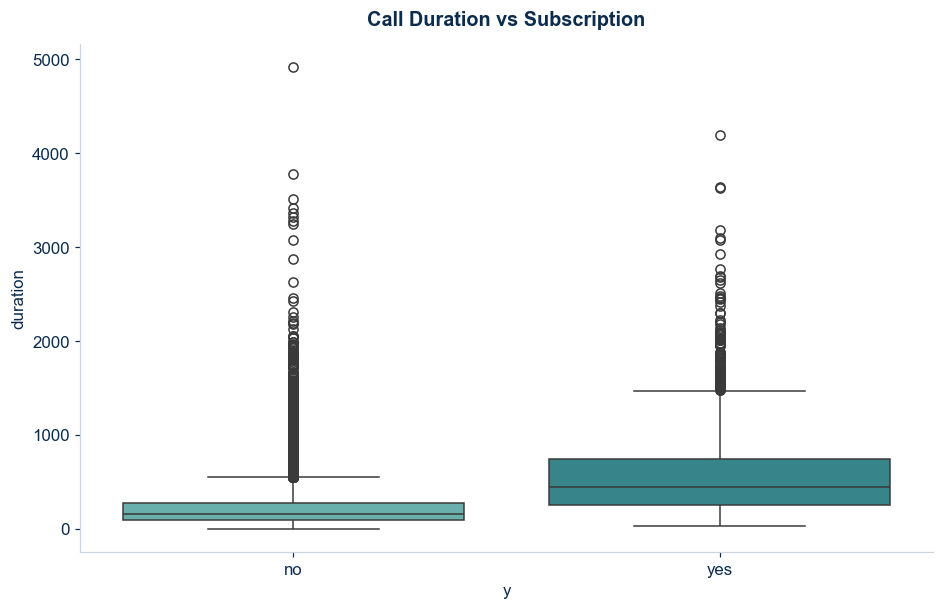

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='y', y='duration',palette=BRAND_PALETTE[2:])

plt.title('Call Duration vs Subscription')
plt.show()

**Insight:** subscribers talked for a median of 449 seconds against 164 for non-subscribers, but call duration is only known after the call, so it is excluded from the model.

### Occupation: students and retirees subscribe most 

In [39]:
job_subscription = pd.crosstab(
    df['job'],
    df['y'],
    normalize='index'
) * 100

job_subscription

y,no,yes
job,,
admin.,87.033305,12.966695
blue-collar,93.104939,6.895061
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.738068,25.261932
self-employed,89.514426,10.485574
services,91.857827,8.142173
student,68.571429,31.428571


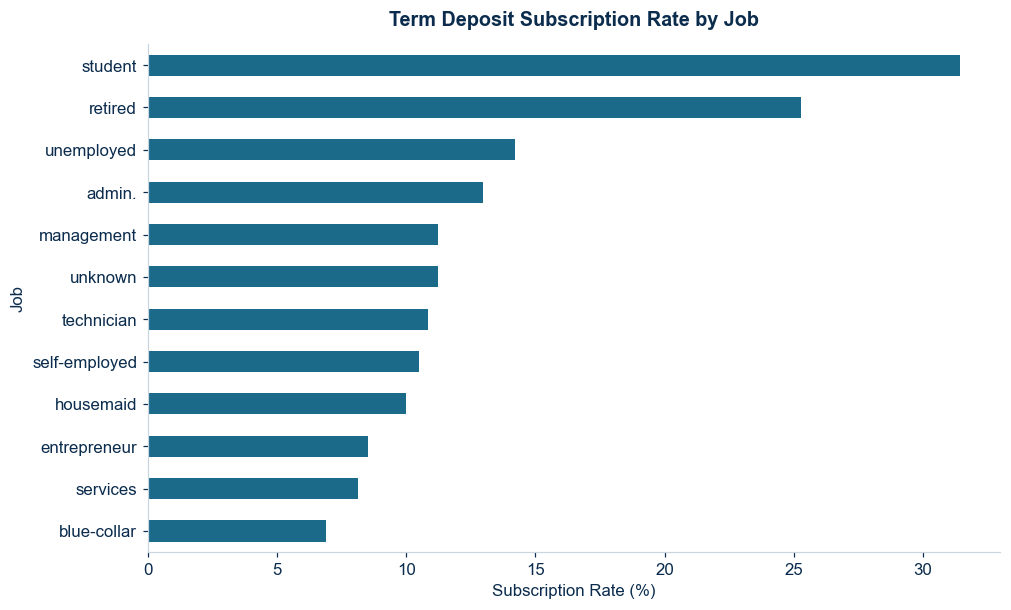

In [40]:
job_subscription['yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Term Deposit Subscription Rate by Job')
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')

plt.show()

## Marketing Opportunity by Occupation

The occupation analysis shows substantial differences in subscription rates.

Students and retired customers have relatively high subscription rates, while blue-collar, services and entrepreneur groups have lower subscription rates.

However, subscription rate alone is not enough to identify a marketing opportunity.

A small segment with a high conversion rate may produce fewer potential customers than a large segment with a lower conversion rate.

For example, there are only 875 students but 9,253 blue-collar workers in the data.

Therefore, I will compare both:

1. The size of each occupation group.
2. The subscription rate within each occupation group.

This provides a more useful view of where additional marketing attention may be worth investigating.

In [41]:
job_opportunity = df.groupby('job').agg(
    customers=('y', 'size'),
    subscribers=('y', lambda x: (x == 'yes').sum()),
    subscription_rate=('y', lambda x: (x == 'yes').mean() * 100)
)

job_opportunity = job_opportunity.sort_values(
    'customers',
    ascending=False
)

job_opportunity

,customers,subscribers,subscription_rate
job,,,
admin.,10419,1351,12.966695
blue-collar,9253,638,6.895061
technician,6739,730,10.832468
services,3967,323,8.142173
management,2924,328,11.217510
retired,1718,434,25.261932
entrepreneur,1456,124,8.516484
self-employed,1421,149,10.485574
housemaid,1060,106,10.000000


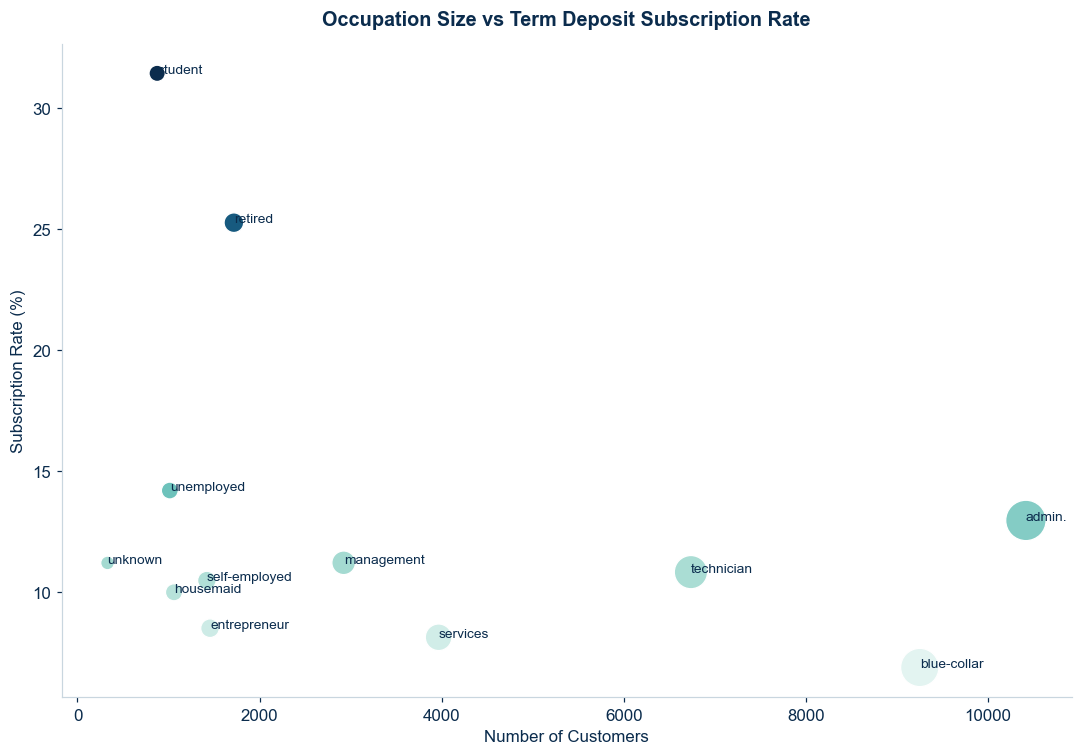

In [42]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=job_opportunity,
    x='customers',
    y='subscription_rate',
    size='customers',
    hue='subscription_rate',
    palette='brand_gradient',
    sizes=(80, 700),
    legend=False
)

for job, row in job_opportunity.iterrows():
    plt.text(
        row['customers'],
        row['subscription_rate'],
        job,
        fontsize=9,
        ha='left'
    )

plt.title('Occupation Size vs Term Deposit Subscription Rate')
plt.xlabel('Number of Customers')
plt.ylabel('Subscription Rate (%)')

sns.despine()
plt.tight_layout()
plt.show()

### Insight

The occupation analysis shows that marketing opportunity should not be judged only by conversion rate.

Students and retired customers have relatively high subscription rates, suggesting strong historical interest in the product. However, larger groups such as **blue-collar workers** , **administration** and **technicians** may contain a larger number of customers who could potentially be reached.

The lower subscription rates among some larger occupational groups do not prove that these customers are uninterested. They may reflect differences in income, financial circumstances, campaign targeting, contact method or the way the product was presented.

These groups could therefore be investigated further using the predictive model rather than being excluded from future campaigns.

### Age: a U-shape, with the youngest and oldest customers subscribing most

In [43]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        '<25',
        '25-34',
        '35-44',
        '45-54',
        '55-64',
        '65+'
    ]
)
age_subscription = pd.crosstab(
    df['age_group'],
    df['y'],
    normalize='index'
) * 100

age_subscription

y,no,yes
age_group,,
<25,79.039039,20.960961
25-34,88.278092,11.721908
35-44,91.494665,8.505335
45-54,91.305929,8.694071
55-64,84.778940,15.221060
65+,53.074434,46.925566


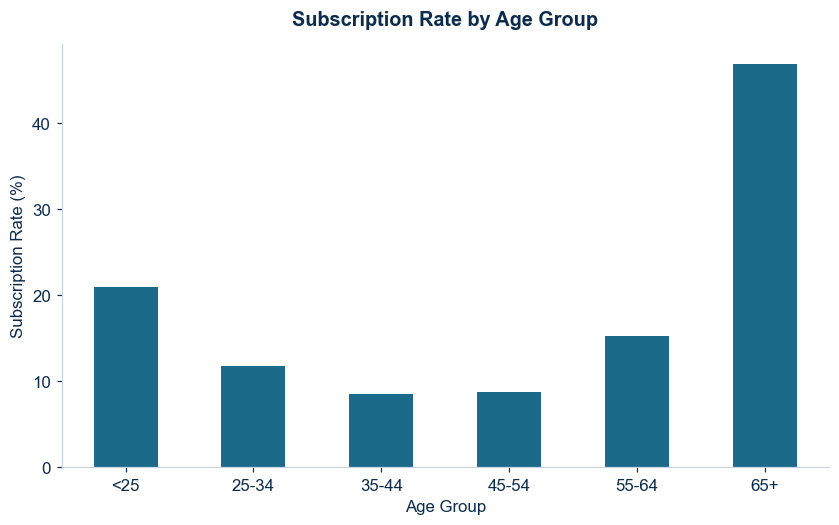

In [44]:
age_subscription['yes'].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

**Insight:** subscription follows a U-shape, with 21.0% under 25 and 46.9% over 65, against about 8.5% for ages 35-54. The over-65 group is small (618 customers).

### Contact method: cellular converts almost three times better than landline 

In [45]:
contact_subscription = pd.crosstab(
    df['contact'],
    df['y'],
    normalize='index'
) * 100

contact_subscription

y,no,yes
contact,,
cellular,85.261144,14.738856
telephone,94.767635,5.232365


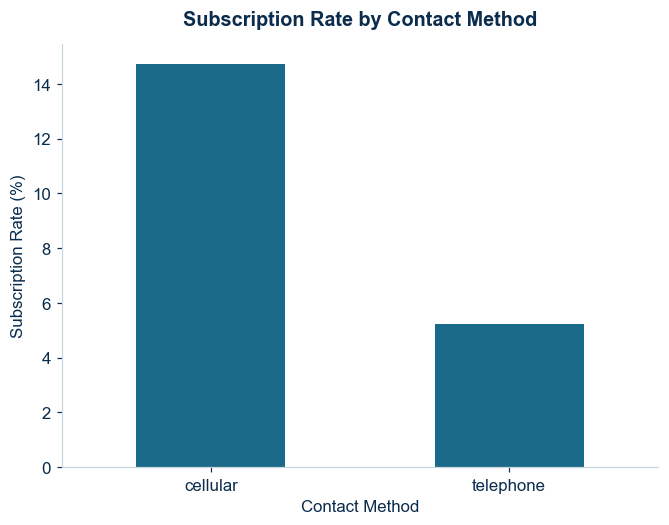

In [46]:
contact_subscription['yes'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

**Cellular contact converted at 14.7% against 5.2% for landline telephone, almost three times better.** The gap is not only a calendar effect: cellular beat landline in 7 of the 10 months.

**So what:** call customers on their mobile first, and prioritise customers who can be reached by mobile.

### Past success is the strongest signal 

In [47]:
poutcome_subscription = pd.crosstab(
    df['poutcome'],
    df['y'],
    normalize='index'
) * 100

poutcome_subscription

y,no,yes
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167618,8.832382
success,34.887109,65.112891


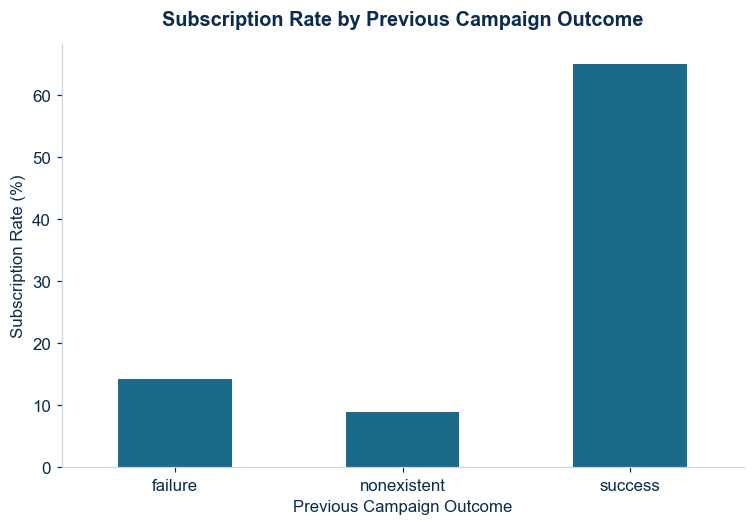

In [48]:
poutcome_subscription['yes'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

**A previous success is by far the strongest signal.** 65.1% of customers whose previous campaign succeeded subscribed again (1,373 customers), against 14.2% after a previous failure (4,252) and 8.8% with no previous campaign outcome (35,551). The overall rate is 11.3%.

**So what:** previous campaign history belongs in any customer prioritisation, and it is the basis of the three segments in Chapter 5.

### Calling the same customer again and again stops paying off 

In [49]:
df['campaign_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 2, 3, 5, 10, 100],
    labels=[
        '1',
        '2',
        '3',
        '4-5',
        '6-10',
        '10+'
    ]
)

In [50]:
campaign_group_subscription = pd.crosstab(
    df['campaign_group'],
    df['y'],
    normalize='index'
) * 100

campaign_group_subscription

y,no,yes
campaign_group,,
1,86.962686,13.037314
2,88.540878,11.459122
3,89.250936,10.749064
4-5,91.315604,8.684396
6-10,93.680445,6.319555
10+,96.892980,3.107020


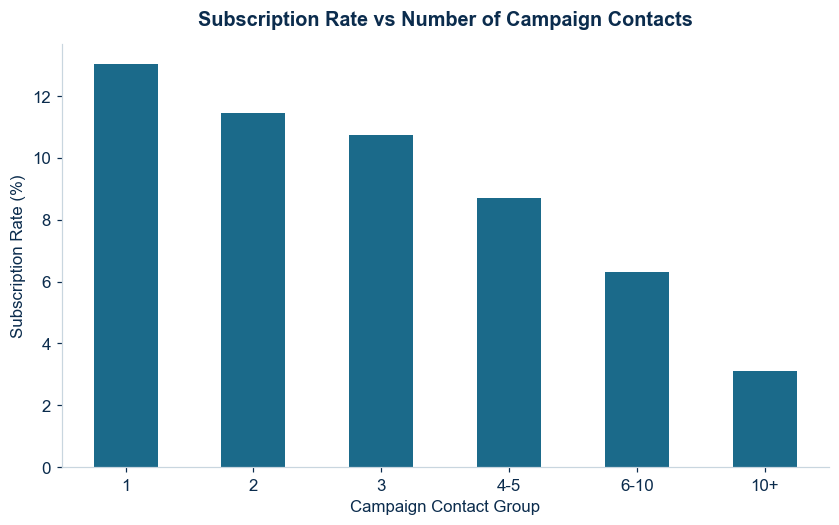

In [51]:
campaign_group_subscription['yes'].plot(
    kind='bar',
    figsize=(9,5)
)

plt.title('Subscription Rate vs Number of Campaign Contacts')
plt.xlabel('Campaign Contact Group')
plt.ylabel('Subscription Rate (%)')

plt.xticks(rotation=0)

plt.show()

## Campaign Contact Frequency and Potential Campaign Fatigue

The number of contacts made to a customer during the current campaign provides an important marketing signal.

The subscription rate is highest among customers contacted once and gradually decreases as the number of contacts increases:

- 1 contact: approximately 13.0% subscribed
- 2 contacts: approximately 11.5%
- 3 contacts: approximately 10.7%
- 4–5 contacts: approximately 8.7%
- 6–10 contacts: approximately 6.3%
- 10+ contacts: approximately 3.1%

This pattern is consistent with diminishing returns from repeated contacts.

However, this should not be interpreted as proof that repeated calls cause customers to reject the product. Customers who require many contacts may already be harder to convert.

**So what:** from the third contact onward the subscription rate (10.7%) falls below the 11.3% campaign average, so the bank should cap attempts per customer.

The practical implication is that the bank should monitor the number of attempts per customer and consider whether continuing to contact low-propensity customers is an efficient use of marketing resources.

### Education: higher education converts better, but occupation matters more 

In [52]:
education_target = pd.crosstab(
    df['education'],
    df['y'],
    normalize='index'
) * 100

education_target

y,no,yes
education,,
basic.4y,89.750958,10.249042
basic.6y,91.793976,8.206024
basic.9y,92.175352,7.824648
high.school,89.161060,10.838940
illiterate,77.777778,22.222222
professional.course,88.645038,11.354962
university.degree,86.279184,13.720816
unknown,85.491329,14.508671


## Education and Potential Customer Awareness

Education level is associated with differences in term-deposit subscription rates.

Customers with a university degree have a subscription rate of approximately 13.7%, compared with approximately 7.8% among customers with basic 9-year education.

However, education level should not be interpreted as a direct measure of financial knowledge or awareness.

The dataset does not contain information about:

- financial literacy,
- knowledge of term deposits,
- understanding of interest rates,
- household income,
- previous financial education,
- or reasons for rejecting the product.

Therefore, the results do not show that customers with lower educational attainment need an awareness programme.

Instead, they suggest a useful marketing hypothesis: the bank could test whether simpler product explanations, clearer communication of benefits and more accessible financial education improve engagement among customer groups with lower historical subscription rates.

In [53]:
education_job = pd.crosstab(
    df['education'],
    df['job'],
    normalize='index'
) * 100

education_job

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
education,,,,,,,,,,,,
basic.4y,1.843870,55.507663,3.280651,11.350575,2.394636,14.295977,2.227011,3.160920,0.622605,1.388889,2.681992,1.245211
basic.6y,6.591008,62.199913,3.099083,3.360978,3.710170,3.273680,1.091227,9.864688,0.567438,3.797468,1.484068,0.960279
basic.9y,8.254756,59.933830,3.473945,1.555004,2.746071,2.398677,3.639371,6.418528,1.637717,6.352357,3.076923,0.512821
high.school,34.997897,9.230446,2.460050,1.829268,3.132885,2.901598,1.240538,28.174937,3.753154,9.167368,2.722876,0.388982
illiterate,5.555556,44.444444,11.111111,5.555556,0.000000,16.666667,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000
professional.course,6.927481,8.645038,2.576336,1.125954,1.698473,4.599237,3.206107,4.160305,0.820611,63.301527,2.709924,0.229008
university.degree,47.270635,0.772772,5.014798,1.142716,16.959882,2.334758,6.289050,1.422230,1.397567,14.871753,2.153897,0.369944
unknown,14.393064,26.242775,3.294798,2.427746,7.109827,5.606936,1.676301,8.670520,9.653179,12.254335,1.098266,7.572254


In [54]:
education_job_subscription = (
    df.groupby(['education', 'job'])['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .reset_index(name='subscription_rate')
)

education_job_subscription.head()

,education,job,subscription_rate
0,basic.4y,admin.,12.987013
1,basic.4y,blue-collar,5.306299
2,basic.4y,entrepreneur,5.109489
3,basic.4y,housemaid,10.759494
4,basic.4y,management,5.000000


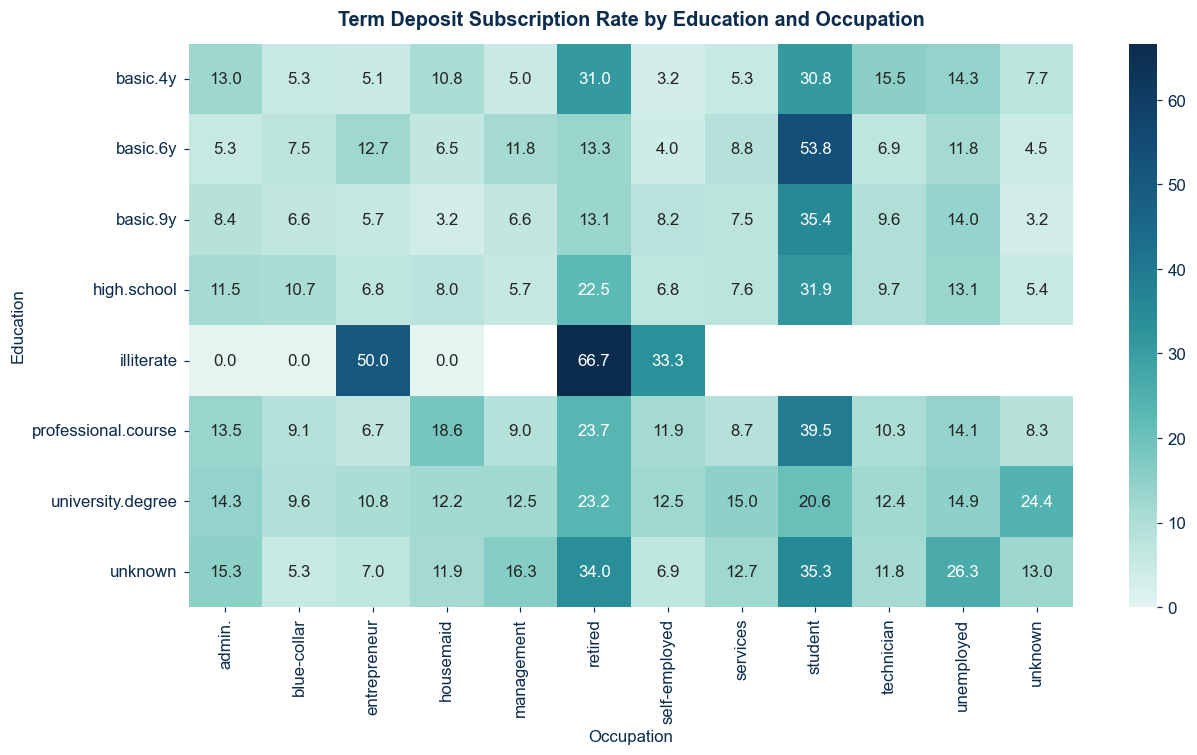

In [55]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    education_job_subscription.pivot(
        index='education',
        columns='job',
        values='subscription_rate'
    ),
    annot=True,
    fmt='.1f',
    cmap='brand_gradient'
)

plt.title('Term Deposit Subscription Rate by Education and Occupation')
plt.xlabel('Occupation')
plt.ylabel('Education')

plt.tight_layout()
plt.show()

**Insight:** university graduates convert at 13.7% against 7.8% for basic 9-year education, but occupation matters more. Across education levels, students convert at roughly 21-54%, retirees at 13-34% and blue-collar workers at 5-11% (ignoring the tiny "illiterate" group).

**So what:** past success, cellular contact, students, retirees, over-65s and early attempts all point to the same warm-prospect profile, while repeated calls and landline contact point away from it.

# Chapter 4 · The context: timing and the economy

Everything so far describes customers. But the calls also happened at different times, and the economy moved a lot between 2008 and 2010: Euribor fell from about 5% to below 1%.

In [56]:
monthly_summary = df.groupby('month').agg(
    customers=('y', 'size'),
    subscribers=('y', lambda x: (x == 'yes').sum()),
    subscription_rate=('y', lambda x: (x == 'yes').mean() * 100)
)

monthly_summary = monthly_summary.sort_values(
    'subscription_rate',
    ascending=False
)

monthly_summary

,customers,subscribers,subscription_rate
month,,,
mar,546,276,50.549451
dec,182,89,48.901099
sep,570,256,44.912281
oct,717,315,43.933054
apr,2631,539,20.486507
aug,6176,655,10.605570
jun,5318,559,10.511470
nov,4100,416,10.146341
jul,7169,648,9.038918


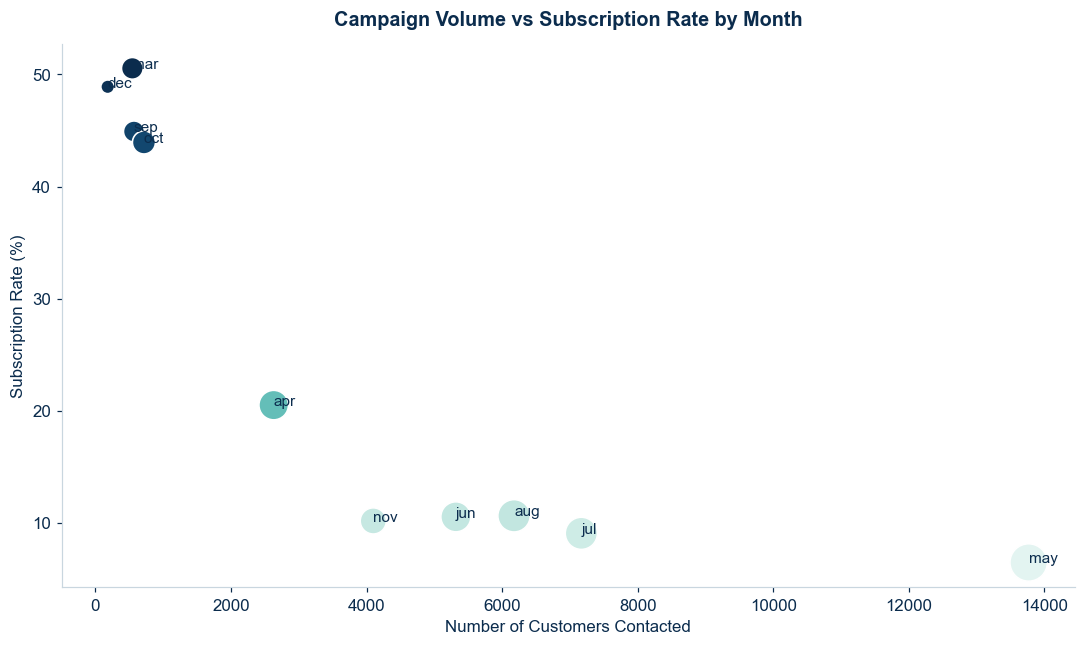

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=monthly_summary,
    x='customers',
    y='subscription_rate',
    size='subscribers',
    hue='subscription_rate',
    palette='brand_gradient',
    sizes=(80, 600),
    legend=False
)

for month, row in monthly_summary.iterrows():
    plt.text(
        row['customers'],
        row['subscription_rate'],
        month,
        fontsize=10
    )

plt.title('Campaign Volume vs Subscription Rate by Month')
plt.xlabel('Number of Customers Contacted')
plt.ylabel('Subscription Rate (%)')

sns.despine()
plt.tight_layout()
plt.show()

### Insight: timing or the economy?

March, September, October and December convert at 44-51%, but they received only 4.9% of all calls and produced 20.2% of subscriptions. May received 33.4% of the calls and converted at 6.4%.

The high months are not simply full of warm customers: even customers with no previous campaign convert at 35-47% in those months, against 5-8% in May to August. They also coincide with very low Euribor rates (median 0.7-1.5, against about 4.9 in May to August). The file covers May 2008 to November 2010, so month and economic period are mixed together.

**So what:** "call in the good months" is not the lesson. The lesson is that term deposits sell better when interest rates are low, and a high-converting month with few contacts is a test opportunity, not proof that the month is universally better.

## Economic Environment and Term Deposit Demand

The dataset was collected over a period from 2008 to 2010, so customer decisions were made under different economic conditions.

Five macroeconomic variables are available:

- Employment variation rate
- Consumer price index
- Consumer confidence index
- EURIBOR 3-month interest rate
- Number of employees

These variables provide context for understanding why customer behaviour may change across campaign periods.

A term deposit is a savings product, so the attractiveness of the product may depend on the wider economic environment, interest rates, employment conditions and consumer confidence.

However, these variables are observed at the campaign-period level rather than being individual customer measurements. Therefore, the analysis identifies associations with the economic environment rather than proving that an individual customer's decision was caused by a particular economic variable.

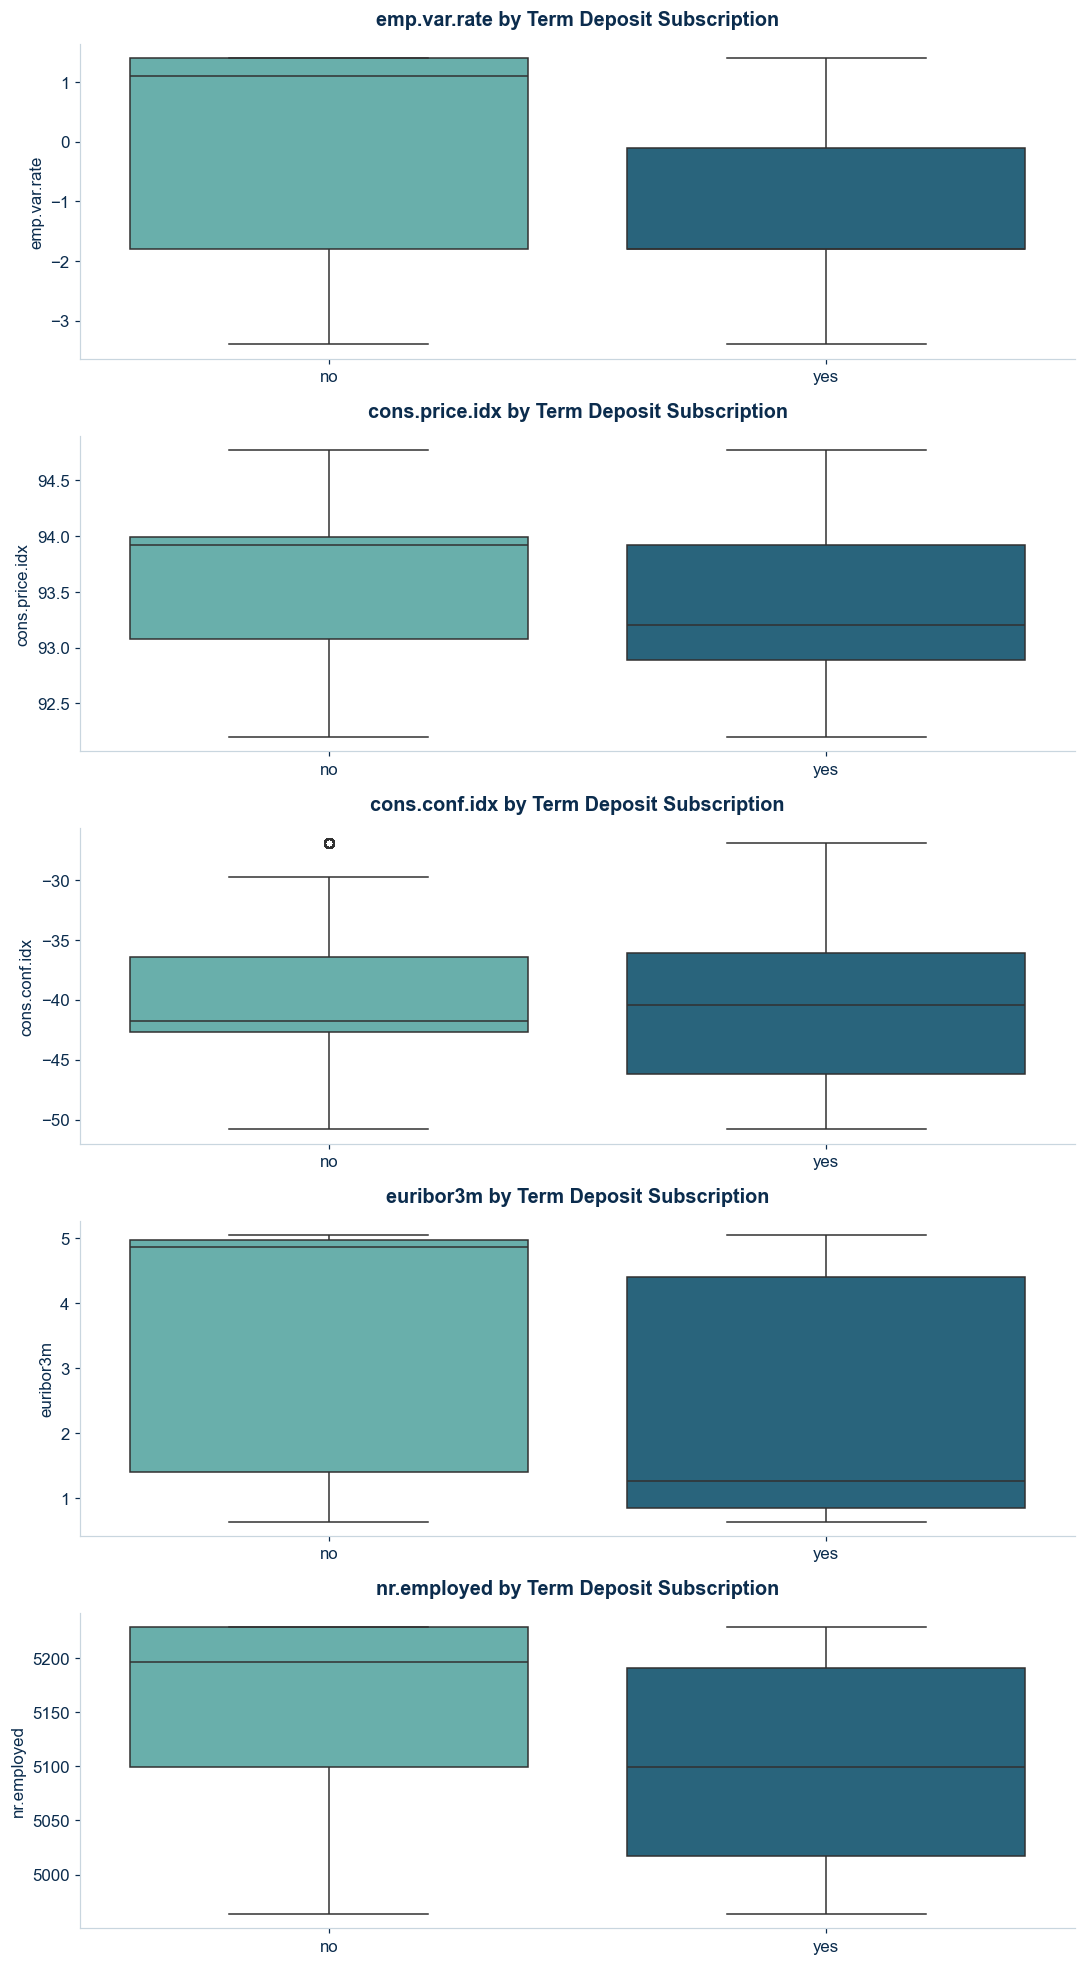

In [58]:
economic_variables = [
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

fig, axes = plt.subplots(
    5, 1,
    figsize=(10, 18)
)

for ax, variable in zip(axes, economic_variables):
    
    sns.boxplot(
        data=df,
        x='y',
        y=variable,
        hue='y',
        palette='brand_gradient',
        legend=False,
        ax=ax
    )
    
    ax.set_title(
        f'{variable} by Term Deposit Subscription'
    )
    
    ax.set_xlabel('')
    
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Interpreting the Economic Variables

The economic variables should be interpreted as indicators of the wider campaign environment rather than direct explanations of individual customer behaviour.

For example, changes in interest rates, consumer confidence and employment conditions may coincide with changes in subscription rates.

The analysis therefore asks:

> "During which economic conditions did customers historically show higher or lower subscription rates?"

rather than:

> "Did this economic variable cause this individual customer to subscribe?"

This distinction is important because the dataset is observational and the economic variables are closely linked to time and campaign periods.

### Insight: subscribers were contacted in a different economy

Subscribers were contacted when Euribor was low (median 1.27 against 4.86 for non-subscribers). The employment variation rate was also lower (-1.8 against 1.1) and the number of employed people was lower (5,099 against 5,196).

The subscription rate was 24% when Euribor was at or below 1.5, and about 5% when it was above 3. These variables move together (correlations above 0.9), so treat them as one "economic climate" signal.

**So what:** the model's top two features are `euribor3m` and `nr.employed`, so much of its power comes from knowing the period. Retrain it on each new campaign wave.

# Chapter 5 · Coverage and segments: three kinds of customer

## Was the Previous Campaign Reaching Enough Customers?

One question for the marketing team is whether the bank was repeatedly contacting the same customers or reaching new customers.

The dataset contains two useful variables:

- `pdays`: number of days since the customer was last contacted in a previous campaign. A value of 999 indicates that the customer was not previously contacted.
- `previous`: number of contacts performed before the current campaign.

These variables allow us to distinguish customers with previous campaign history from customers who appear to be new to the previous campaign.

It is important not to interpret `pdays = 999` as meaning that the customer has never been contacted by the bank. It only indicates that the customer was not contacted in the previous campaign represented by this variable.

In [59]:
# Create a simple indicator for previous campaign contact

df['previously_contacted'] = (
    df['pdays'] != 999
).astype(int)

contact_history = df['previously_contacted'].value_counts()

contact_history.index = [
    'No previous campaign contact',
    'Previously contacted'
]

contact_history

No previous campaign contact    39661
Previously contacted             1515
Name: count, dtype: int64

In [60]:
contact_history_pct = (
    df['previously_contacted']
    .value_counts(normalize=True)
    .mul(100)
)

contact_history_pct.index = [
    'No previous campaign contact',
    'Previously contacted'
]

contact_history_pct

No previous campaign contact    96.320672
Previously contacted             3.679328
Name: proportion, dtype: float64

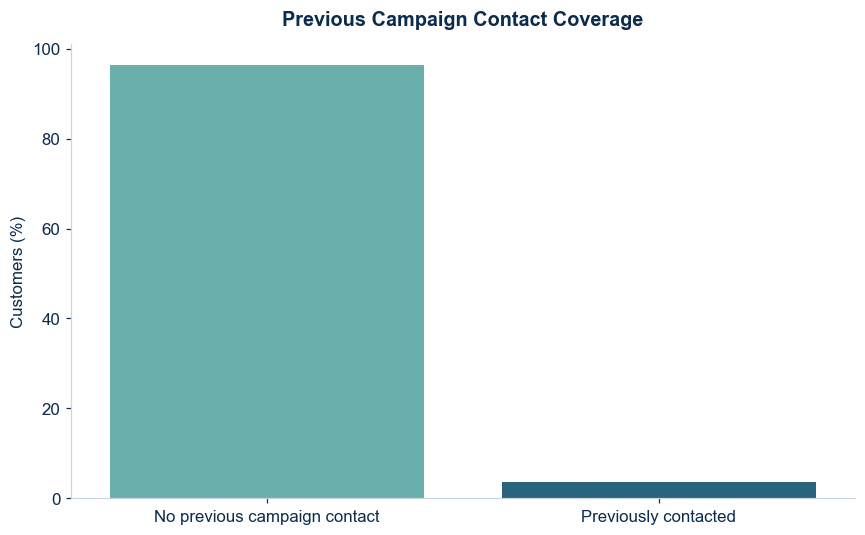

In [61]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=contact_history_pct.index,
    y=contact_history_pct.values,
    hue=contact_history_pct.index,
    palette='brand_gradient',
    legend=False
)

plt.title('Previous Campaign Contact Coverage')
plt.xlabel('')
plt.ylabel('Customers (%)')

sns.despine()
plt.tight_layout()
plt.show()

### Who Was Missing From Previous Campaign Contact?

A high proportion of customers with no previous campaign contact does not automatically mean that the campaign was poorly managed.

It may indicate that the bank was deliberately focusing on customers who had already been identified as prospects, while other customers were not included in the previous campaign.

To investigate this further, I will compare previous-contact coverage across months, occupations and education groups.

This helps identify whether some customer segments may have been under-represented in previous campaigns.

In [62]:
monthly_contact_coverage = (
    df.groupby('month')['previously_contacted']
      .agg(['count', 'sum', 'mean'])
)

monthly_contact_coverage.columns = [
    'Customers',
    'Previously Contacted',
    'Previous Contact Rate'
]

monthly_contact_coverage['Previous Contact Rate'] *= 100

monthly_contact_coverage.sort_values(
    'Previous Contact Rate'
)

,Customers,Previously Contacted,Previous Contact Rate
month,,,
jul,7169,118,1.645976
may,13767,248,1.801409
jun,5318,154,2.895825
aug,6176,236,3.821244
apr,2631,115,4.370962
nov,4100,190,4.634146
mar,546,90,16.483516
oct,717,157,21.896792
dec,182,46,25.274725


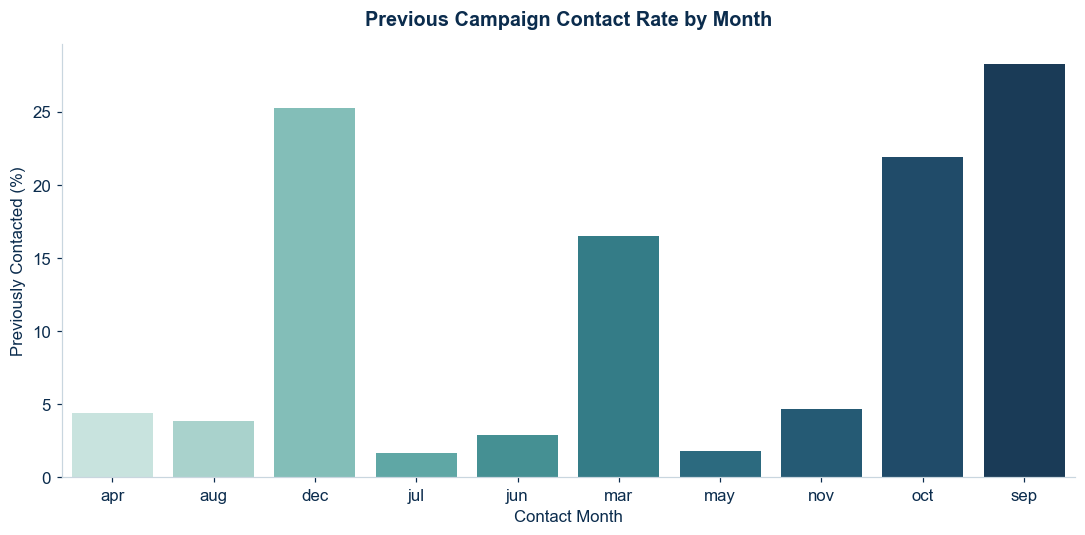

In [63]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=monthly_contact_coverage.reset_index(),
    x='month',
    y='Previous Contact Rate',
    hue='month',
    palette='brand_gradient',
    legend=False
)

plt.title('Previous Campaign Contact Rate by Month')
plt.xlabel('Contact Month')
plt.ylabel('Previously Contacted (%)')

sns.despine()
plt.tight_layout()
plt.show()

**Finding:** 96.3% of customers (39,661) had no previous campaign contact, and only 3.7% (1,515) had one. Previous-contact coverage was highest in Sep (28.2%), Dec (25.3%), Oct (21.9%) and lowest in Jul (1.6%) and May (1.8%).

### Insight

The monthly analysis helps identify whether previous campaign coverage was consistent throughout the campaign period.

Months with a lower previous-contact rate contain a larger proportion of customers who had not been contacted in the previous campaign. This may represent an opportunity to investigate whether customer acquisition, campaign scheduling or campaign capacity differed across months.

However, the dataset alone cannot tell us whether these customers were deliberately excluded, were newly acquired, or were simply outside the targeting criteria of the previous campaign.

Therefore, the result should be treated as a campaign coverage signal rather than proof of a missed marketing opportunity.

## Why Were So Many Customers Not Previously Contacted?

A large number of customers have no recorded previous campaign contact.

This does not necessarily mean that the bank failed to market to these customers. The dataset only tells us that a previous campaign contact was not recorded.

One possible explanation is that the campaign strategy concentrated on customers with an existing relationship or previous campaign history.

The previous campaign outcome provides an important clue. Customers with a previous successful campaign outcome have a much higher subscription rate in the current campaign than customers with no previous campaign outcome.

This suggests that previous campaign engagement is an important predictor of future response.

However, it also raises a business question:

> Are customers without previous campaign history being given enough opportunity to discover the product?

This should be investigated as a campaign coverage question rather than assumed to be a marketing failure (the outcome chart is in Chapter 3).

### Key Finding

Previous campaign success is strongly associated with current campaign subscription.

Approximately 65% of customers whose previous campaign outcome was successful subscribed in the current campaign, compared with approximately 8.8% of customers with no previous campaign outcome.

This suggests that previous engagement history is highly informative for campaign targeting.

The bank could therefore use previous campaign history as one component of customer prioritisation.

At the same time, customers without previous campaign history should not automatically be excluded. Instead, they could be tested through lower-cost introductory campaigns to determine whether new-customer acquisition can be improved.

![Project workflow](customer_segment_workflow.png)

## From Mass Marketing to Customer Segmentation

The analysis suggests that customers should not necessarily receive the same marketing treatment.

Three broad historical segments can be identified:

**1. Previously successful customers**

These customers have the strongest historical subscription rate and may be suitable for higher-priority follow-up.

**2. Previously contacted but unsuccessful customers**

These customers show lower response than the successful group but higher response than customers with no previous campaign outcome. They may benefit from a different message or offer.

**3. Customers with no previous campaign outcome**

This group has the lowest historical subscription rate. Rather than repeatedly using expensive direct calls, the bank could test lower-cost introductory communication and measure whether awareness and engagement improve.

These are descriptive segments based on historical data, not guarantees of future behaviour.

**Insight:** the three segments are very different in size and response.

- **Warm customers:** 3.3% of the list (1,373 customers) with a 65.1% response, yet only 19.3% of all subscribers.
- **Re-engagement customers:** 10.3% of the list (4,252) with a 14.2% response, and 13.0% of subscribers.
- **New customers:** 86.3% of the list (35,551) with an 8.8% response, but 67.7% of all subscribers.

**So what:** warm customers deserve priority, but most subscribers still come from the new-customer group, so that group needs smart targeting rather than exclusion. That is the job of the model in the next chapter.

# Chapter 6 · The model: can we rank customers before the call?

EDA shows who subscribed, but not who will subscribe next time. So we build a model that ranks customers by likelihood *before* the call.

Three design decisions follow from the EDA:
- **`duration` is excluded**, since it is only known after the call.
- **`pdays = 999` becomes a `previously_contacted` flag**, because 96% of customers have no previous contact.
- **Oversampling happens inside the training pipeline only**, because 88.7% of customers are "no".

### Feature Engineering

In [64]:
model_df = df.copy()

In [65]:
model_df['pdays_actual'] = model_df['pdays'].replace(999, np.nan)

In [66]:
model_df[['pdays', 'previously_contacted', 'pdays_actual']].head(10)

,pdays,previously_contacted,pdays_actual
0,999,0,NaN
1,999,0,NaN
2,999,0,NaN
3,999,0,NaN
4,999,0,NaN
5,999,0,NaN
6,999,0,NaN
7,999,0,NaN
8,999,0,NaN
9,999,0,NaN


In [67]:
drop_columns = [
    'y',
    'duration',
    'pdays',
    'age_group',
    'campaign_group'
]

X = model_df.drop(columns=drop_columns)
y = model_df['y']

In [68]:
y = y.map({
    'no': 0,
    'yes': 1
})

In [69]:
y.value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

### Identify categorical and numerical variables

In [70]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical Features:
['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'pdays_actual']


### Train test split 

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [72]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training set: (32940, 20)
Testing set: (8236, 20)

Training target:
y
0    0.887341
1    0.112659
Name: proportion, dtype: float64

Testing target:
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


### Handle Class Imbalance

The target variable is imbalanced because relatively few customers subscribe to the term deposit.

RandomOverSampler will be used only inside the training process. The test set will remain unchanged so that model performance is evaluated on data with the original class distribution.

RandomOverSampler duplicates observations from the minority class rather than creating synthetic observations.

### Create preprocessing pipeline

In [73]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

In [74]:
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore'
        ))
    ]
)

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#### We are using a pipeline, Because it prevents data leakage.
1. The preprocessing is learned only from the training data and then applied to the test data.
2. This is much better than manually encoding the entire dataset before splitting it.

### Model 1: Logistic regression 

In [76]:
logistic_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ('classifier', LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

#### Train Logistic regression 

In [77]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previously_contacted',
                                                   'pdays_actual']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('sampler',
                 RandomOverSampler(random_state=42, sampling_strategy=0.5)),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [78]:
y_pred_lr = logistic_model.predict(X_test)

In [79]:
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [80]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_lr))

Accuracy: 0.8722680913064594
Precision: 0.4480737018425461
Recall: 0.5765086206896551
F1 Score: 0.5042412818096136
ROC-AUC: 0.8004056873195176
PR-AUC: 0.44648062788564663


In [81]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['No', 'Yes']
    )
)

              precision    recall  f1-score   support

          No       0.94      0.91      0.93      7308
         Yes       0.45      0.58      0.50       928

    accuracy                           0.87      8236
   macro avg       0.70      0.74      0.72      8236
weighted avg       0.89      0.87      0.88      8236



### Confusion matrix 

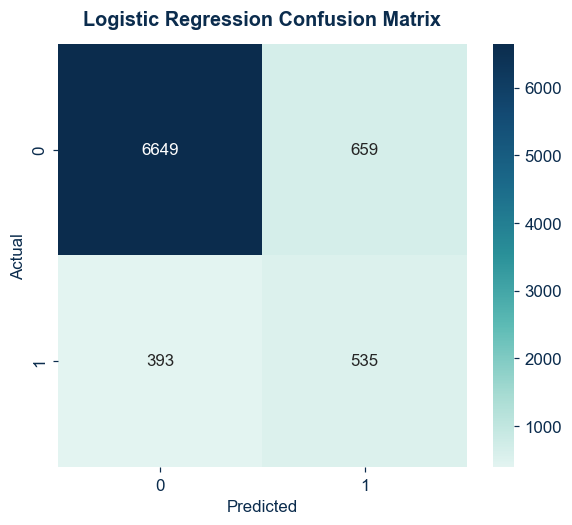

In [82]:
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='brand_gradient'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

### Decision Tree 

In [83]:
decision_tree = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ('classifier', DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=50,
            random_state=42
        ))
    ]
)

In [84]:
decision_tree.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previously_contacted',
                                                   'pdays_actual']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('sampler',
                 RandomOverSampler(random_state=42, sampling_strategy=0.5)),
                ('classifier',
                 DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                        random_state=42))])

In [85]:
y_pred_dt = decision_tree.predict(X_test)

y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [86]:
print("Decision Tree")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt))

print("Recall:",
      recall_score(y_test, y_pred_dt))

print("F1:",
      f1_score(y_test, y_pred_dt))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_dt))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_dt))

Decision Tree
Accuracy: 0.8772462360369111
Precision: 0.4641932700603969
Recall: 0.5797413793103449
F1: 0.5155725922376617
ROC-AUC: 0.804596890158164
PR-AUC: 0.46051634568612354


### Model 3: Random Forest

In [87]:
random_forest = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [88]:
random_forest.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previously_contacted',
                                                   'pdays_actual']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImput...tegy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('sampler',
                 RandomOverSampler(random_state=42, sampling_strategy=0.5)),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [89]:
y_pred_rf = random_forest.predict(X_test)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [90]:
print("Random Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_rf))

Random Forest
Accuracy: 0.8859883438562409
Precision: 0.4946236559139785
Recall: 0.5452586206896551
F1: 0.5187083546899026
ROC-AUC: 0.8038622795283392
PR-AUC: 0.48270074826795156


### Model 4: XGBoost

In [91]:
xgb_model = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ('classifier', XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [92]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previously_contacted',
                                                   'pdays_actual']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImput...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [93]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [94]:
print("XGBoost")

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1:",
      f1_score(y_test, y_pred_xgb))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_xgb))

print("PR-AUC:",
      average_precision_score(y_test, y_prob_xgb))

XGBoost
Accuracy: 0.8808887809616318
Precision: 0.4765279007971656
Recall: 0.5797413793103449
F1: 0.5230918813806514
ROC-AUC: 0.8121132308948154
PR-AUC: 0.47899153591406946


### Compare all four models

In [95]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],

    'PR-AUC': [
        average_precision_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_dt),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.872268,0.448074,0.576509,0.504241,0.800406,0.446481
1,Decision Tree,0.877246,0.464193,0.579741,0.515573,0.804597,0.460516
2,Random Forest,0.885988,0.494624,0.545259,0.518708,0.803862,0.482701
3,XGBoost,0.880889,0.476528,0.579741,0.523092,0.812113,0.478992


In [96]:
results.sort_values(
    by='PR-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Random Forest,0.885988,0.494624,0.545259,0.518708,0.803862,0.482701
3,XGBoost,0.880889,0.476528,0.579741,0.523092,0.812113,0.478992
1,Decision Tree,0.877246,0.464193,0.579741,0.515573,0.804597,0.460516
0,Logistic Regression,0.872268,0.448074,0.576509,0.504241,0.800406,0.446481


### ROC curves

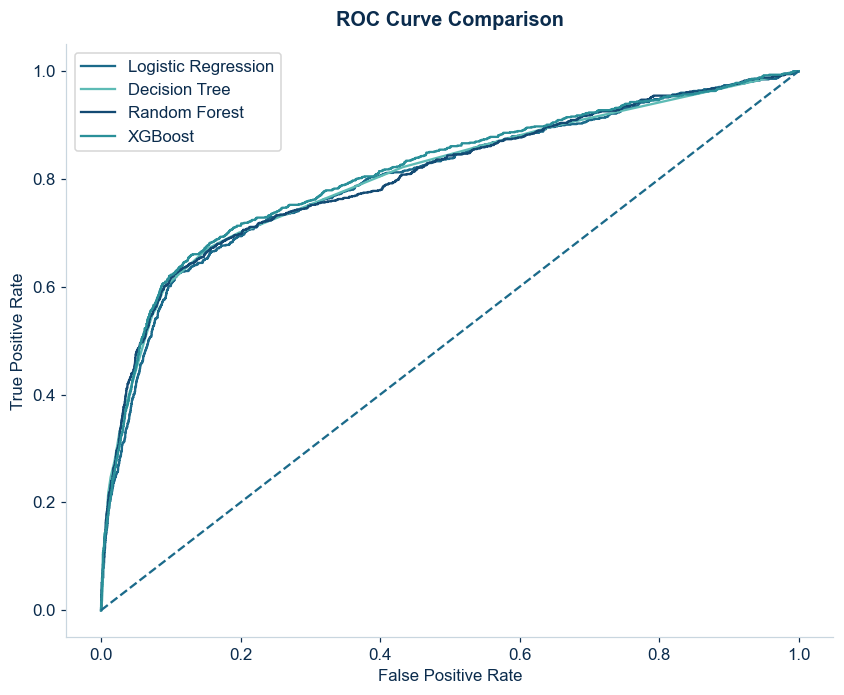

In [97]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label='Logistic Regression'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label='Decision Tree'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label='Random Forest'
)

plt.plot(
     fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

plt.plot(
    [0, 1],
    [0, 1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

### Precision-Recall curves

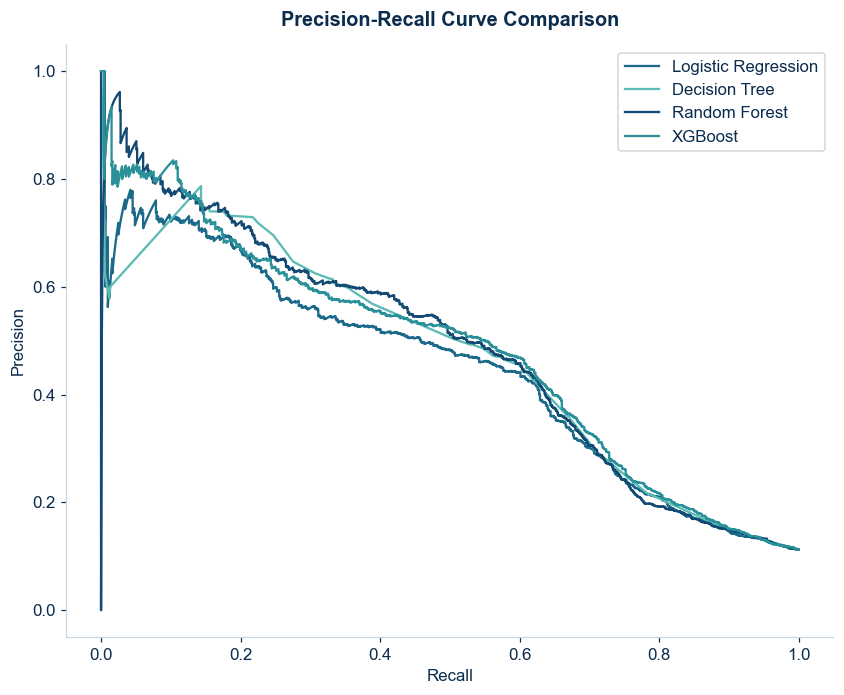

In [98]:
precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob_lr
)

precision_dt, recall_dt, _ = precision_recall_curve(
    y_test,
    y_prob_dt
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(9, 7))

plt.plot(
    recall_lr,
    precision_lr,
    label='Logistic Regression'
)

plt.plot(
    recall_dt,
    precision_dt,
    label='Decision Tree'
)

plt.plot(
    recall_rf,
    precision_rf,
    label='Random Forest'
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label='XGBoost'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()

plt.show()

### Model comparison: a near tie

All four models land within 0.04 of each other on PR-AUC (0.446-0.483) and within 0.012 on ROC-AUC (0.800-0.812), and their curves overlap. The algorithm barely matters; the signal in the data does.

**So what:** we choose by business need, not by decimals. Next we tune XGBoost to see whether it separates from the pack.

## Hyperparameter Tuning

The baseline models provide a starting point. I will now tune the XGBoost model to see whether different combinations of model settings improve predictive performance.

The sampler remains inside the pipeline so that balancing is performed only on the training portion of each cross-validation fold.


In [99]:
from sklearn.model_selection import GridSearchCV

In [100]:
xgb_tuning_pipeline = ImbPipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('sampler', RandomOverSampler(
            sampling_strategy=0.5,
            random_state=42
        )),
        ('classifier', XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [101]:
param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [3, 4],
    'classifier__learning_rate': [0.05, 0.10],
    'classifier__subsample': [0.8, 1.0]
}


In [102]:
grid_search = GridSearchCV(
    estimator=xgb_tuning_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [103]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'campaign',
                                                                          'previous',
                                                                          'emp.var.rate',
                                                                          'cons.price.idx',
                                                                          'cons.conf.idx',
                                                                          'euribor3m',
                                                                          'nr.employed',
                                                                          'previously_contacted',
                                                                          'pdays_actual']),
                                                                        ('cat',
                                                                         Pipeline(s...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': [3, 4],
                         'classifier__n_estimators': [200, 400],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='average_precision', verbose=1)

In [104]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation PR-AUC:")
print(grid_search.best_score_)

Best parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Best cross-validation PR-AUC:
0.46663761853646113


In [105]:
tuned_xgb = grid_search.best_estimator_

In [106]:
y_pred_tuned = tuned_xgb.predict(X_test)

y_prob_tuned = tuned_xgb.predict_proba(X_test)[:, 1]

In [107]:
print("Tuned XGBoost Performance")
print("-------------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1:", f1_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print("PR-AUC:", average_precision_score(y_test, y_prob_tuned))

Tuned XGBoost Performance
-------------------------
Accuracy: 0.8808887809616318
Precision: 0.4769765421372719
Recall: 0.5915948275862069
F1: 0.5281385281385281
ROC-AUC: 0.8110190562303001
PR-AUC: 0.48411034953536497


In [108]:
# Add the tuned XGBoost to the comparison table (safe to re-run)
results = results[results['Model'] != 'Tuned XGBoost']
results = pd.concat([results, pd.DataFrame({
    'Model': ['Tuned XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_tuned)],
    'Precision': [precision_score(y_test, y_pred_tuned)],
    'Recall': [recall_score(y_test, y_pred_tuned)],
    'F1': [f1_score(y_test, y_pred_tuned)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_tuned)],
    'PR-AUC': [average_precision_score(y_test, y_prob_tuned)]
})], ignore_index=True)

In [109]:
results = results.sort_values(
    by='PR-AUC',
    ascending=False
).reset_index(drop=True)

display(results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.880889,0.476977,0.591595,0.528139,0.811019,0.484110
1,Random Forest,0.885988,0.494624,0.545259,0.518708,0.803862,0.482701
2,XGBoost,0.880889,0.476528,0.579741,0.523092,0.812113,0.478992
3,Decision Tree,0.877246,0.464193,0.579741,0.515573,0.804597,0.460516
4,Logistic Regression,0.872268,0.448074,0.576509,0.504241,0.800406,0.446481


In [110]:
best_model_name = results.loc[0, 'Model']

print("Model with the highest PR-AUC:")
print(best_model_name)

Model with the highest PR-AUC:
Tuned XGBoost


### Choosing the final model

Tuned XGBoost edges the table (PR-AUC 0.484, F1 0.528, recall 59.2%), but only by 0.001 PR-AUC over Random Forest (0.483). That is a tie.

**We take Random Forest as the final model** because it has the highest precision (49.5%) and accuracy (88.6%), which means the fewest wasted calls for a call-centre team. If the bank prefers cheap channels where missing a subscriber costs more than a wasted message, switch to tuned XGBoost.

## Final model deep-dive: Random Forest

Random Forest is the final model for the reasons given above: it has the highest precision and accuracy, so the fewest wasted calls.

It is an ensemble of decision trees that can capture non-linear relationships between customer characteristics and the likelihood of subscribing. Because the target is imbalanced, RandomOverSampler is part of the training pipeline and the test data is never oversampled.

In [111]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")
print(f"PR-AUC:    {rf_pr_auc:.4f}")


Random Forest Performance
-------------------------
Accuracy:  0.8860
Precision: 0.4946
Recall:    0.5453
F1 Score:  0.5187
ROC-AUC:   0.8039
PR-AUC:    0.4827


### Random Forest Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as likely or unlikely to subscribe.

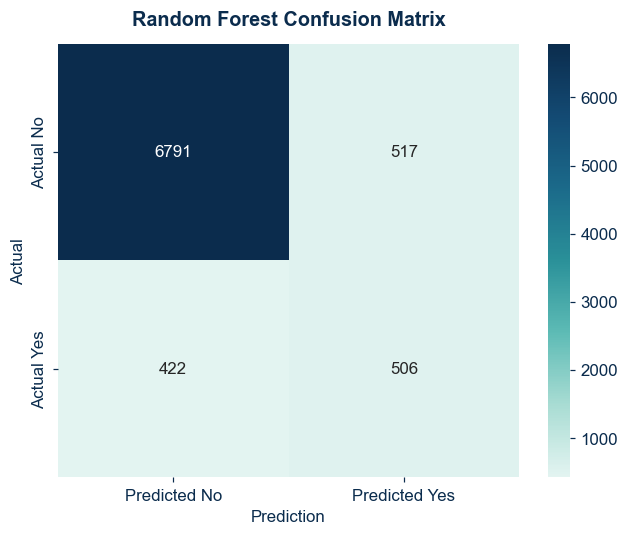

In [112]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='brand_gradient',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

**Insight:** of the 928 subscribers in the test set, Random Forest finds 506 and misses 422. Of the 1,023 customers it flags, 506 subscribe (49.5%), against 11.3% when calling at random.

### Random Forest ROC Curve

The ROC curve shows how well the Random Forest separates customers who subscribed from those who did not.

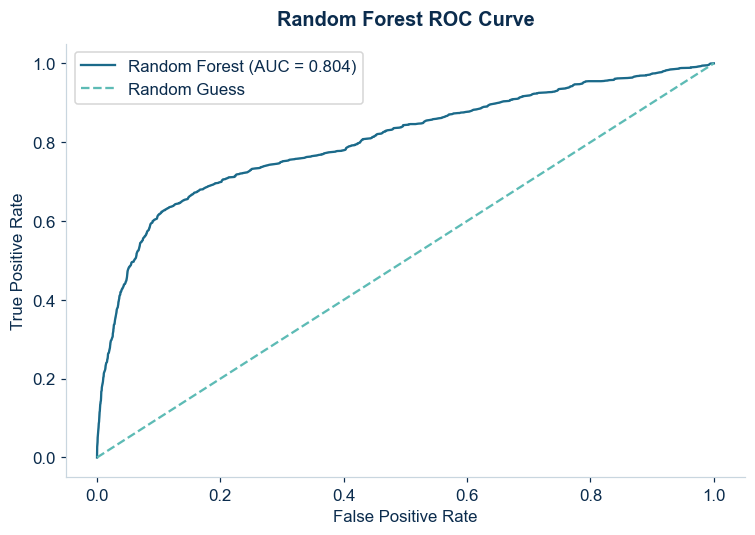

In [113]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

sns.lineplot(
    x=fpr_rf,
    y=tpr_rf,
    label=f'Random Forest (AUC = {rf_roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Random Forest Precision-Recall Curve

Because relatively few customers subscribe to the term deposit, the Precision-Recall curve provides a useful view of how well the model identifies potential subscribers.

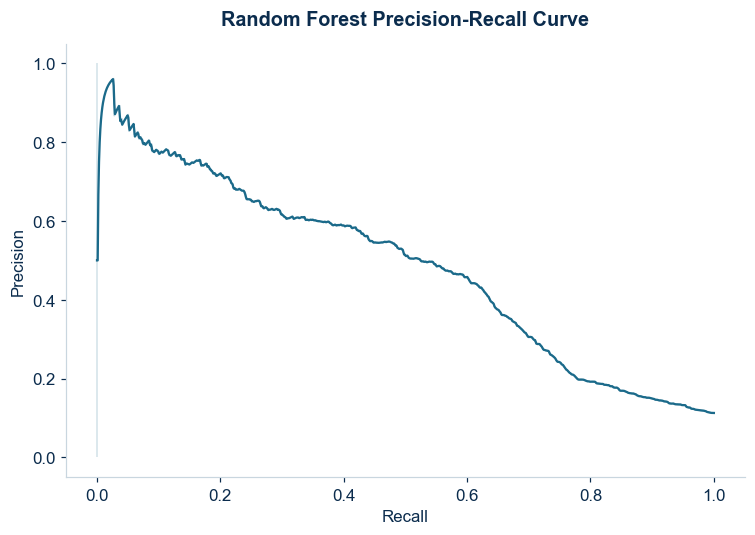

In [114]:
precision_rf, recall_rf, thresholds_pr_rf = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(7, 5))

sns.lineplot(
    x=recall_rf,
    y=precision_rf
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')

sns.despine()
plt.tight_layout()
plt.show()

In [115]:
feature_names = random_forest.named_steps[
    'preprocessor'
].get_feature_names_out()

importance_values = random_forest.named_steps[
    'classifier'
].feature_importances_

feature_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

feature_importance_rf = feature_importance_rf.sort_values(
    'Importance',
    ascending=False
)

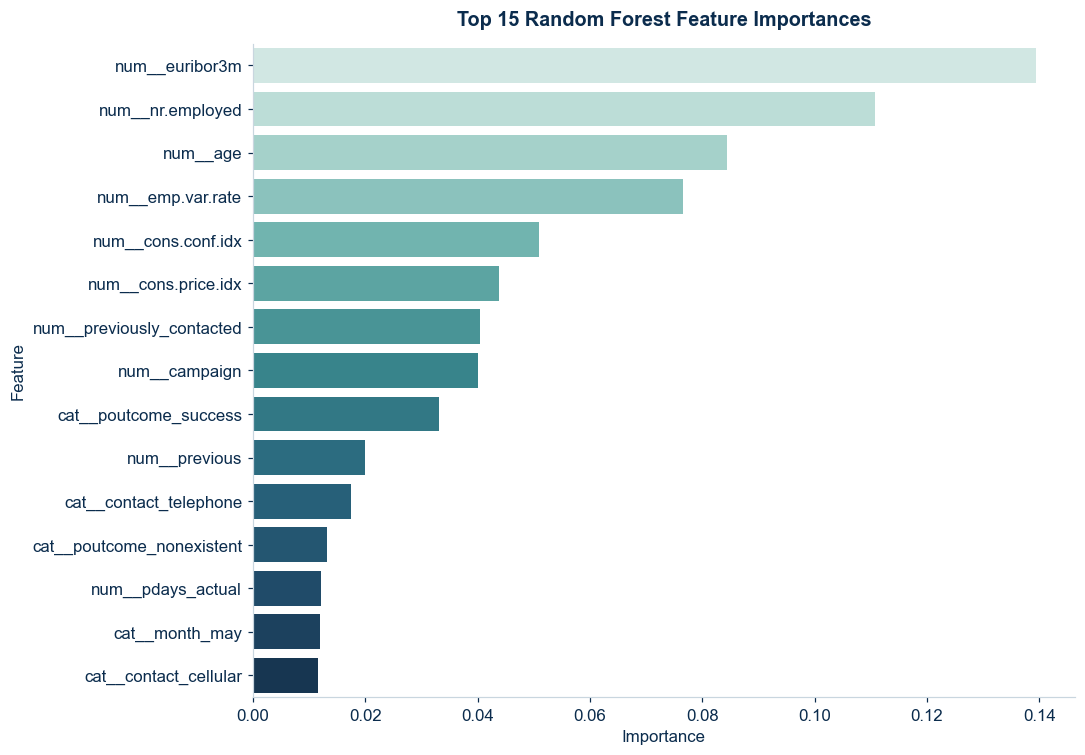

In [116]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_rf.head(15),
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False,
    palette='brand_gradient'
)

plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

sns.despine()
plt.tight_layout()
plt.show()

**Insight:** the model leans most on `euribor3m` (0.139), `nr.employed` (0.111), `age` (0.084), `emp.var.rate` (0.077) and `cons.conf.idx` (0.051). The economic climate dominates, and previous-campaign features follow behind. Importance shows what the model uses, not what causes a subscription.

In [117]:
# Create a table showing actual outcome and Random Forest prediction

rf_predictions = X_test.copy()

rf_predictions['Actual'] = y_test.values
rf_predictions['Predicted'] = y_pred_rf
rf_predictions['Subscription_Probability'] = y_prob_rf

rf_predictions.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,pdays_actual,Actual,Predicted,Subscription_Probability
8490,35,services,married,high.school,unknown,no,no,telephone,jun,wed,...,1.4,94.465,-41.8,4.864,5228.1,0,NaN,0,0,0.050873
40844,30,student,single,professional.course,no,yes,no,cellular,sep,tue,...,-1.1,94.199,-37.5,0.880,4963.6,1,6.0,1,1,0.929621
35681,37,self-employed,single,basic.4y,no,yes,no,cellular,may,mon,...,-1.8,92.893,-46.2,1.244,5099.1,0,NaN,0,0,0.266839
35994,31,blue-collar,single,professional.course,no,no,no,cellular,may,tue,...,-1.8,92.893,-46.2,1.266,5099.1,0,NaN,0,0,0.368679
21961,31,technician,married,university.degree,no,unknown,unknown,cellular,aug,wed,...,1.4,93.444,-36.1,4.964,5228.1,0,NaN,0,0,0.345311
11522,52,blue-collar,married,basic.9y,no,no,no,telephone,jun,fri,...,1.4,94.465,-41.8,4.959,5228.1,0,NaN,0,0,0.087343
35058,48,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,-1.8,92.893,-46.2,1.250,5099.1,0,NaN,0,0,0.238347
31093,46,admin.,married,high.school,unknown,yes,no,cellular,may,wed,...,-1.8,92.893,-46.2,1.334,5099.1,0,NaN,0,0,0.111528
32880,35,services,divorced,university.degree,no,yes,no,cellular,may,mon,...,-1.8,92.893,-46.2,1.299,5099.1,0,NaN,0,0,0.191879
22655,58,technician,divorced,professional.course,no,no,no,cellular,aug,fri,...,1.4,93.444,-36.1,4.964,5228.1,0,NaN,0,0,0.132940


In [118]:
# Show customers with the highest predicted probability

top_customers = rf_predictions.sort_values(
    by='Subscription_Probability',
    ascending=False
)

top_customers.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,pdays_actual,Actual,Predicted,Subscription_Probability
40434,47,management,married,university.degree,no,yes,no,cellular,aug,mon,...,-1.7,94.027,-38.3,0.904,4991.6,1,3.0,0,1,0.978590
39220,34,admin.,single,university.degree,no,yes,no,cellular,mar,tue,...,-1.8,93.369,-34.8,0.652,5008.7,1,6.0,1,1,0.977719
40061,29,admin.,single,high.school,no,yes,no,cellular,jul,thu,...,-1.7,94.215,-40.3,0.810,4991.6,1,6.0,1,1,0.975709
40797,58,admin.,married,high.school,no,no,no,cellular,sep,thu,...,-1.1,94.199,-37.5,0.878,4963.6,1,6.0,1,1,0.974190
40380,48,admin.,single,university.degree,no,yes,no,cellular,aug,wed,...,-1.7,94.027,-38.3,0.900,4991.6,1,0.0,1,1,0.972618
40556,69,retired,married,high.school,no,yes,yes,cellular,sep,wed,...,-1.1,94.199,-37.5,0.886,4963.6,1,6.0,1,1,0.971847
40454,65,retired,married,professional.course,no,yes,no,cellular,aug,tue,...,-1.7,94.027,-38.3,0.904,4991.6,1,6.0,1,1,0.970809
40473,66,admin.,divorced,university.degree,no,yes,no,cellular,aug,wed,...,-1.7,94.027,-38.3,0.903,4991.6,1,6.0,1,1,0.968381
39218,34,admin.,single,high.school,no,no,no,cellular,mar,tue,...,-1.8,93.369,-34.8,0.652,5008.7,1,6.0,1,1,0.965003
40645,36,management,divorced,university.degree,no,yes,no,cellular,sep,tue,...,-1.1,94.199,-37.5,0.881,4963.6,1,6.0,1,1,0.960992


In [119]:
rf_predictions['Predicted_Subscription'] = np.where(
    rf_predictions['Subscription_Probability'] >= 0.50,
    'yes',
    'no'
)

rf_predictions.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,pdays_actual,Actual,Predicted,Subscription_Probability,Predicted_Subscription
8490,35,services,married,high.school,unknown,no,no,telephone,jun,wed,...,94.465,-41.8,4.864,5228.1,0,NaN,0,0,0.050873,no
40844,30,student,single,professional.course,no,yes,no,cellular,sep,tue,...,94.199,-37.5,0.880,4963.6,1,6.0,1,1,0.929621,yes
35681,37,self-employed,single,basic.4y,no,yes,no,cellular,may,mon,...,92.893,-46.2,1.244,5099.1,0,NaN,0,0,0.266839,no
35994,31,blue-collar,single,professional.course,no,no,no,cellular,may,tue,...,92.893,-46.2,1.266,5099.1,0,NaN,0,0,0.368679,no
21961,31,technician,married,university.degree,no,unknown,unknown,cellular,aug,wed,...,93.444,-36.1,4.964,5228.1,0,NaN,0,0,0.345311,no
11522,52,blue-collar,married,basic.9y,no,no,no,telephone,jun,fri,...,94.465,-41.8,4.959,5228.1,0,NaN,0,0,0.087343,no
35058,48,blue-collar,married,basic.9y,no,no,no,cellular,may,fri,...,92.893,-46.2,1.250,5099.1,0,NaN,0,0,0.238347,no
31093,46,admin.,married,high.school,unknown,yes,no,cellular,may,wed,...,92.893,-46.2,1.334,5099.1,0,NaN,0,0,0.111528,no
32880,35,services,divorced,university.degree,no,yes,no,cellular,may,mon,...,92.893,-46.2,1.299,5099.1,0,NaN,0,0,0.191879,no
22655,58,technician,divorced,professional.course,no,no,no,cellular,aug,fri,...,93.444,-36.1,4.964,5228.1,0,NaN,0,0,0.132940,no


### From scores to a call list

To see how much of the campaign the bank can skip, we sort the test customers by score, cut them into ten equal groups (deciles) and check how many actual subscribers each group holds.

In [120]:
from IPython.display import Markdown

gains_df = pd.DataFrame({'probability': y_prob_rf, 'actual': y_test.values})
gains_df['decile'] = pd.qcut(gains_df['probability'].rank(method='first', ascending=False),
                             10, labels=range(1, 11))

gains = gains_df.groupby('decile', observed=True)['actual'].agg(customers='size', subscribers='sum')
gains['subscription_rate_%'] = gains['subscribers'] / gains['customers'] * 100
gains['cumulative_capture_%'] = gains['subscribers'].cumsum() / gains['subscribers'].sum() * 100
display(gains.round(1))

base_rate = y_test.mean() * 100
top_decile = gains.iloc[0]
top_three = gains.iloc[2]
display(Markdown(
    f"**Insight:** the top 10% of customers by score convert at {top_decile['subscription_rate_%']:.0f}% "
    f"(against {base_rate:.0f}% overall), and the top 30% hold {top_three['cumulative_capture_%']:.0f}% of all subscribers. "
    f"A call list trimmed to the top 30% would reach that share of subscribers with 30% of the calls."
))

,customers,subscribers,subscription_rate_%,cumulative_capture_%
decile,,,,
1,824,447,54.2,48.2
2,824,160,19.4,65.4
3,823,67,8.1,72.6
4,824,36,4.4,76.5
5,823,52,6.3,82.1
6,824,42,5.1,86.6
7,823,39,4.7,90.8
8,824,36,4.4,94.7
9,823,21,2.6,97.0


**Insight:** the top 10% of customers by score convert at 54% (against 11% overall), and the top 30% hold 73% of all subscribers. A call list trimmed to the top 30% would reach that share of subscribers with 30% of the calls.

### Create customer propensity scores

In [121]:
scored_customers = X_test.copy()

scored_customers['actual_y'] = y_test.values

scored_customers['propensity_score'] = y_prob_rf

scored_customers = scored_customers.sort_values(
    by='propensity_score',
    ascending=False
)

scored_customers.head(20)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,pdays_actual,actual_y,propensity_score
40434,47,management,married,university.degree,no,yes,no,cellular,aug,mon,...,success,-1.7,94.027,-38.3,0.904,4991.6,1,3.0,0,0.978590
39220,34,admin.,single,university.degree,no,yes,no,cellular,mar,tue,...,success,-1.8,93.369,-34.8,0.652,5008.7,1,6.0,1,0.977719
40061,29,admin.,single,high.school,no,yes,no,cellular,jul,thu,...,success,-1.7,94.215,-40.3,0.810,4991.6,1,6.0,1,0.975709
40797,58,admin.,married,high.school,no,no,no,cellular,sep,thu,...,success,-1.1,94.199,-37.5,0.878,4963.6,1,6.0,1,0.974190
40380,48,admin.,single,university.degree,no,yes,no,cellular,aug,wed,...,success,-1.7,94.027,-38.3,0.900,4991.6,1,0.0,1,0.972618
40556,69,retired,married,high.school,no,yes,yes,cellular,sep,wed,...,success,-1.1,94.199,-37.5,0.886,4963.6,1,6.0,1,0.971847
40454,65,retired,married,professional.course,no,yes,no,cellular,aug,tue,...,success,-1.7,94.027,-38.3,0.904,4991.6,1,6.0,1,0.970809
40473,66,admin.,divorced,university.degree,no,yes,no,cellular,aug,wed,...,success,-1.7,94.027,-38.3,0.903,4991.6,1,6.0,1,0.968381
39218,34,admin.,single,high.school,no,no,no,cellular,mar,tue,...,success,-1.8,93.369,-34.8,0.652,5008.7,1,6.0,1,0.965003
40645,36,management,divorced,university.degree,no,yes,no,cellular,sep,tue,...,success,-1.1,94.199,-37.5,0.881,4963.6,1,6.0,1,0.960992


### Check multiple customer segments

In [122]:
scored_customers.groupby(
    'contact'
)['propensity_score'].mean()

contact
cellular     0.275639
telephone    0.128923
Name: propensity_score, dtype: float64

In [123]:
scored_customers.groupby(
    'job'
)['propensity_score'].mean().sort_values(
    ascending=False
)

job
student          0.451463
retired          0.400374
unemployed       0.277383
admin.           0.248436
self-employed    0.240152
technician       0.209738
housemaid        0.209115
management       0.207148
unknown          0.196892
entrepreneur     0.194778
services         0.181812
blue-collar      0.161196
Name: propensity_score, dtype: float64

In [124]:
scored_customers.groupby(
    'poutcome'
)['propensity_score'].mean().sort_values(
    ascending=False
)

poutcome
success        0.788203
failure        0.285902
nonexistent    0.191705
Name: propensity_score, dtype: float64

In [125]:
from IPython.display import Markdown

seg_scores = scored_customers.groupby('poutcome')['propensity_score'].mean().sort_values(ascending=False)
display(Markdown(
    "**Insight:** average model score by previous outcome, highest to lowest: "
    + ', '.join(f"{name} ({value:.2f})" for name, value in seg_scores.items())
    + ". Compare this order with the historical rates (success 65.1%, failure 14.2%, nonexistent 8.8%). "
      "Oversampling inflates absolute scores, so read the order, not the level."
))

**Insight:** average model score by previous outcome, highest to lowest: success (0.79), failure (0.29), nonexistent (0.19). Compare this order with the historical rates (success 65.1%, failure 14.2%, nonexistent 8.8%). Oversampling inflates absolute scores, so read the order, not the level.

## Which model for which channel?

All numbers below come from the held-out test set (8,236 customers, 928 subscribers, 11.3% baseline rate).

* **Random Forest, the default for call centres and advisors.** It has the highest precision (49.5%), so about half of the customers it flags subscribe, 4.4 times better than random calling. Recall is 54.5%, F1 is 0.519 and accuracy is 88.6%, the highest of all models.
* **Tuned XGBoost, for cheap outreach (SMS, email, app notifications).** It has the highest recall (59.2%), F1 (0.528) and PR-AUC (0.484). Precision is 47.7% (4.2 times random), which matters little when an extra message costs almost nothing.
* **Logistic Regression, the transparent benchmark.** Recall is 57.7% and precision 44.8% (4.0 times random). It is the weakest on PR-AUC (0.446), but its coefficients are the easiest to explain to the business.

### The baseline reality check

* **Predicting "no" for everyone** would score 88.7% accuracy and find zero subscribers, which is why accuracy alone is not used.
* **Every model is roughly 4 times better than random.** Precision is 44.8-49.5% against the 11.3% baseline, and recall is 54.5-59.2%.
* **The models miss about 4 in 10 subscribers.** Random Forest finds 506 of 928 and misses 422, so scores should rank customers, not be treated as certainties.

# Chapter 7 · The plan: what the marketing team should do next

- **Warm customers (3.3% of the list, 65.1% historical response):** call first and personalise the conversation using their previous interaction.
- **Re-engagement customers (10.3%, 14.2%):** make a new offer with a softer follow-up, and limit repeat attempts.
- **New or uncontacted customers (86.3%, 8.8%):** use low-cost introductory messaging and test it. This group is large and holds 67.7% of all subscribers, so rank it with the model rather than excluding it.
- **Work down the score:** call in score order using the decile table above, instead of calling the whole list.
- **Cap repeat calls:** from the third contact the subscription rate drops below the 11.3% campaign average.
- **Prefer mobile numbers:** cellular converted at 14.7% against 5.2% for landline.
- **Match the message to the climate:** term deposits sold best when interest rates were low, so stress safety, a guaranteed return and a clear lock-in term.
- **Retrain every campaign wave:** the model leans on the economic indicators, so its scores go stale as the economy moves.

### Limitations
- **Imbalanced target:** only about 11% subscribe, so precision, recall and PR-AUC matter more than accuracy.
- **Random split, not a time split:** train and test customers come from the same 2008-2010 period, so results may look better than they will on a future campaign wave.
- **Time proxy:** the economic indicators partly stand in for the campaign period, so validate on the newest wave before relying on them.
- **Observational data:** results show historical associations, not proof that a variable causes a subscription.
- **Scores are rankings:** oversampling shifts predicted probabilities, so use them to rank customers rather than as exact chances.